In [ ]:
# ارزیابی های مدل
# BaseVAE = Vanilla-AE
# Beta-VAE
# HierarchicalVAE
# FactorVAE
# LadderVAE

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

########################################
# CPU Optimization
########################################

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"

torch.set_num_threads(8)
torch.set_num_interop_threads(8)

device = torch.device("cpu")

class MelDataset(Dataset):

    def __init__(self, root):
        self.files = [
            os.path.join(root, f)
            for f in os.listdir(root)
            if f.endswith(".pt")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        x = torch.load(self.files[idx], weights_only=True)

        # force fixed size 80x80
        if x.shape[2] > 80:
            x = x[:, :, :80]
        else:
            pad = 80 - x.shape[2]
            x = F.pad(x, (0, pad))

        return x


train_dataset = MelDataset("data/librispeech_mel/train-clean-100")
test_dataset  = MelDataset("data/librispeech_mel/dev-clean")

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=6
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=6
)


In [2]:
x = next(iter(train_loader))
print(x.shape)


torch.Size([32, 1, 80, 80])


In [3]:
####### FactorVAE model
import torch
import torch.nn as nn
import torch.nn.functional as F


class FactorVAE(nn.Module):

    def __init__(self, latent_dim=120, input_shape=(1,80,80)):
        super().__init__()

        self.latent_dim = latent_dim

        ################################
        # Encoder
        ################################

        self.encoder = nn.Sequential(

            nn.Conv2d(1,32,3,2,1), nn.ReLU(),
            nn.Conv2d(32,64,3,2,1), nn.ReLU(),
            nn.Conv2d(64,128,3,2,1), nn.ReLU(),
            nn.Conv2d(128,256,3,2,1), nn.ReLU()
        )

        with torch.no_grad():
            dummy = torch.zeros(1,*input_shape)
            h = self.encoder(dummy)
            self.enc_shape = h.shape[1:]
            self.flatten_dim = h.view(1,-1).shape[1]

        ################################
        # Latent
        ################################

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_var = nn.Linear(self.flatten_dim, latent_dim)

        ################################
        # Decoder
        ################################

        self.decoder_input = nn.Linear(latent_dim,self.flatten_dim)

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(256,128,3,2,1,1),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,3,2,1,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,3,2,1,1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,3,2,1,1),
            nn.Sigmoid()
        )


    def encode(self,x):

        h = self.encoder(x)

        h_flat = h.view(x.size(0),-1)

        mu = self.fc_mu(h_flat)
        logvar = self.fc_var(h_flat)

        return mu,logvar


    def reparameterize(self,mu,logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std


    def decode(self,z):

        h = self.decoder_input(z)

        h = h.view(z.size(0),*self.enc_shape)

        return self.decoder(h)


    def forward(self,x):

        mu,logvar = self.encode(x)

        z = self.reparameterize(mu,logvar)

        recon = self.decode(z)

        return recon,mu,logvar,z
#############
class FactorVAEDiscriminator(nn.Module):

    def __init__(self,latent_dim=120):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(latent_dim,1000),
            nn.LeakyReLU(0.2),

            nn.Linear(1000,1000),
            nn.LeakyReLU(0.2),

            nn.Linear(1000,1000),
            nn.LeakyReLU(0.2),

            nn.Linear(1000,2)
        )

    def forward(self,z):

        return self.net(z)
###
# Permutation trick
# برای تخمین Total Correlation
def permute_dims(z):

    B, D = z.size()

    perm_z = []

    for d in range(D):

        perm = torch.randperm(B).to(z.device)

        perm_z.append(z[perm,d])

    perm_z = torch.stack(perm_z,dim=1)

    return perm_z


def factor_vae_loss(recon,x,mu,logvar,z,D,gamma=10):

    ################################
    # reconstruction
    ################################

    recon_loss = F.mse_loss(recon,x)

    ################################
    # KL
    ################################

    kld = -0.5*torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    ################################
    # Total Correlation
    ################################

    logits = D(z)

    tc = (logits[:,0] - logits[:,1]).mean()

    ################################

    loss = recon_loss + kld + gamma*tc

    return loss,recon_loss,kld,tc


In [4]:
# Ladder Model
import torch
import torch.nn as nn
import torch.nn.functional as F


class LadderVAE(nn.Module):

    def __init__(self, latent_dims=[40,40,40]):
        super().__init__()

        z1,z2,z3 = latent_dims

        ################################
        # Bottom-up encoder
        ################################

        self.enc1 = nn.Conv2d(1,32,3,stride=2,padding=1)
        self.enc2 = nn.Conv2d(32,64,3,stride=2,padding=1)
        self.enc3 = nn.Conv2d(64,128,3,stride=2,padding=1)

        ################################
        # q(z|x)
        ################################

        self.q_mu1 = nn.Linear(32*40*40, z1)
        self.q_var1 = nn.Linear(32*40*40, z1)

        self.q_mu2 = nn.Linear(64*20*20, z2)
        self.q_var2 = nn.Linear(64*20*20, z2)

        self.q_mu3 = nn.Linear(128*10*10, z3)
        self.q_var3 = nn.Linear(128*10*10, z3)

        ################################
        # Top-down prior p(z_l | z_{l+1})
        ################################

        self.p_mu2 = nn.Linear(z3, z2)
        self.p_var2 = nn.Linear(z3, z2)

        self.p_mu1 = nn.Linear(z2, z1)
        self.p_var1 = nn.Linear(z2, z1)

        ################################
        # Decoder
        ################################

        self.fc_decode = nn.Linear(z1+z2+z3, 128*10*10)

        self.decoder = nn.Sequential(

            nn.Unflatten(1,(128,10,10)),

            nn.ConvTranspose2d(128,64,3,2,1,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,3,2,1,1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,3,2,1,1),
            nn.Sigmoid()
        )


    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std


    def combine_gaussians(self, mu_q, logvar_q, mu_p, logvar_p):

        var_q = torch.exp(logvar_q)
        var_p = torch.exp(logvar_p)

        var = 1/(1/var_q + 1/var_p)

        mu = var*(mu_q/var_q + mu_p/var_p)

        logvar = torch.log(var)

        return mu, logvar


    def forward(self,x):

        ################################
        # bottom-up
        ################################

        h1 = torch.relu(self.enc1(x))
        h2 = torch.relu(self.enc2(h1))
        h3 = torch.relu(self.enc3(h2))

        q_mu1 = self.q_mu1(h1.view(x.size(0),-1))
        q_var1 = self.q_var1(h1.view(x.size(0),-1))

        q_mu2 = self.q_mu2(h2.view(x.size(0),-1))
        q_var2 = self.q_var2(h2.view(x.size(0),-1))

        q_mu3 = self.q_mu3(h3.view(x.size(0),-1))
        q_var3 = self.q_var3(h3.view(x.size(0),-1))

        ################################
        # top latent
        ################################

        z3 = self.reparameterize(q_mu3,q_var3)

        ################################
        # ladder step z2
        ################################

        p_mu2 = self.p_mu2(z3)
        p_var2 = self.p_var2(z3)

        mu2,logvar2 = self.combine_gaussians(
            q_mu2,q_var2,p_mu2,p_var2
        )

        z2 = self.reparameterize(mu2,logvar2)

        ################################
        # ladder step z1
        ################################

        p_mu1 = self.p_mu1(z2)
        p_var1 = self.p_var1(z2)

        mu1,logvar1 = self.combine_gaussians(
            q_mu1,q_var1,p_mu1,p_var1
        )

        z1 = self.reparameterize(mu1,logvar1)

        ################################
        # decoder
        ################################

        z = torch.cat([z1,z2,z3],dim=1)

        h = self.fc_decode(z)

        recon = self.decoder(h)

        ################################

        mu = torch.cat([mu1,mu2,q_mu3],dim=1)
        logvar = torch.cat([logvar1,logvar2,q_var3],dim=1)

        return recon, mu, logvar


In [5]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

########################################
# CPU Optimization
########################################

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"

torch.set_num_threads(8)
torch.set_num_interop_threads(8)

device = torch.device("cpu")

class MelDataset(Dataset):

    def __init__(self, root):
        self.files = [
            os.path.join(root, f)
            for f in os.listdir(root)
            if f.endswith(".pt")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        x = torch.load(self.files[idx], weights_only=True)

        # force fixed size 80x80
        if x.shape[2] > 80:
            x = x[:, :, :80]
        else:
            pad = 80 - x.shape[2]
            x = F.pad(x, (0, pad))

        return x


train_dataset = MelDataset("data/librispeech_mel/train-clean-100")
test_dataset  = MelDataset("data/librispeech_mel/dev-clean")

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=6
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=6
)

RuntimeError: Error: cannot set number of interop threads after parallel work has started or set_num_interop_threads called

In [6]:
# گام ۱: پیاده‌سازی مدل‌های Baseline
import torch
import torch.nn as nn

class BaseVAE(nn.Module):

    def __init__(self, latent_dim=120, input_shape=(1,128,128)):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,3,stride=2,padding=1), nn.ReLU(),
            nn.Conv2d(32,64,3,stride=2,padding=1), nn.ReLU(),
            nn.Conv2d(64,128,3,stride=2,padding=1), nn.ReLU(),
            nn.Conv2d(128,256,3,stride=2,padding=1), nn.ReLU()
        )

        # محاسبه خودکار سایز خروجی encoder
        with torch.no_grad():
            dummy = torch.zeros(1,*input_shape)
            h = self.encoder(dummy)
            self.flatten_dim = h.view(1,-1).shape[1]

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_var = nn.Linear(self.flatten_dim, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128,64,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )


    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self,x):
    
        h = self.encoder(x)
    
        h_flat = h.view(x.size(0),-1)
    
        mu = self.fc_mu(h_flat)
        logvar = self.fc_var(h_flat)
    
        z = self.reparameterize(mu,logvar)
    
        h_dec = self.decoder_input(z)
    
        h_dec = h_dec.view(x.size(0),256, h.shape[2], h.shape[3])
    
        recon = self.decoder(h_dec)
    
        return recon, mu, logvar


#########################################################

######################
class HierarchicalVAE(nn.Module):

    def __init__(self, latent_dim=120, input_shape=(1,80,80)):
        super().__init__()

        self.dims = [40,40,40]

        self.enc1 = nn.Conv2d(1,32,3,stride=2,padding=1)
        self.enc2 = nn.Conv2d(32,64,3,stride=2,padding=1)
        self.enc3 = nn.Conv2d(64,128,3,stride=2,padding=1)

        # ابعاد صحیح برای 80x80
        self.mu_list = nn.ModuleList([
            nn.Linear(32*40*40,40),
            nn.Linear(64*20*20,40),
            nn.Linear(128*10*10,40)
        ])

        self.var_list = nn.ModuleList([
            nn.Linear(32*40*40,40),
            nn.Linear(64*20*20,40),
            nn.Linear(128*10*10,40)
        ])

        self.decoder = nn.Sequential(

            nn.Linear(120,128*10*10),
            nn.ReLU(),

            nn.Unflatten(1,(128,10,10)),

            nn.ConvTranspose2d(128,64,3,2,1,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,3,2,1,1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,3,2,1,1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std


    def forward(self,x):

        x1 = torch.relu(self.enc1(x))
        x2 = torch.relu(self.enc2(x1))
        x3 = torch.relu(self.enc3(x2))

        mu1 = self.mu_list[0](x1.view(x.size(0),-1))
        mu2 = self.mu_list[1](x2.view(x.size(0),-1))
        mu3 = self.mu_list[2](x3.view(x.size(0),-1))

        logvar1 = self.var_list[0](x1.view(x.size(0),-1))
        logvar2 = self.var_list[1](x2.view(x.size(0),-1))
        logvar3 = self.var_list[2](x3.view(x.size(0),-1))

        mu = torch.cat([mu1,mu2,mu3],dim=1)
        logvar = torch.cat([logvar1,logvar2,logvar3],dim=1)

        z = self.reparameterize(mu,logvar)

        recon = self.decoder(z)

        return recon, mu, logvar

##########################


In [7]:
########################################
# Hierarchical Encoder
########################################

class HierarchicalEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1,32,3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.projections = nn.ModuleList([
            nn.Linear(32,20),
            nn.Linear(64,20),
            nn.Linear(128,20),
            nn.Linear(128,20),
            nn.Linear(128,20),
            nn.Linear(128,20)
        ])

    def forward(self,x):

        f1 = self.conv1(x)
        f2 = self.conv2(f1)
        f3 = self.conv3(f2)
        f4 = self.conv4(f3)

        pooled = [
            self.pool(f1).view(x.size(0),-1),
            self.pool(f2).view(x.size(0),-1),
            self.pool(f3).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
        ]

        z_levels = [
            self.projections[i](pooled[i])
            for i in range(6)
        ]

        z = torch.cat(z_levels, dim=1)

        return z, z_levels


########################################
# Decoder
########################################

class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(120,128*5*5)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128,128,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,4,stride=2,padding=1)
        )

    def forward(self,z):

        x = self.fc(z)
        x = x.view(-1,128,5,5)
        x = self.deconv(x)

        return x


########################################
# Model
########################################

class HDIModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = HierarchicalEncoder()
        self.decoder = Decoder()

    def forward(self,x):

        z, levels = self.encoder(x)
        recon = self.decoder(z)

        return recon, levels

In [8]:
import torch
import numpy as np


def extract_latents_basevae(model, dataloader, device, save_path):
    model.eval()
    model.to(device)

    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)

            h = model.encoder(x)
            h_flat = h.view(x.size(0), -1)

            mu = model.fc_mu(h_flat)
            logvar = model.fc_var(h_flat)

            # برای evaluation معمولا از mu استفاده می‌کنیم
            z = mu

            latents.append(z.cpu().numpy())

    latents = np.concatenate(latents, axis=0)

    np.save(save_path, latents)

    print("saved:", save_path)
    print("shape:", latents.shape)


In [9]:
# اجرای درست برای Vanilla VAE
vanilla_vae = BaseVAE(
    latent_dim=120,
    input_shape=(1, 80, 80)
).to(device)

ckpt = torch.load("vanilla_ae_best.pt", map_location=device, weights_only=False)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    vanilla_vae.load_state_dict(ckpt["model_state_dict"])
else:
    vanilla_vae.load_state_dict(ckpt)

extract_latents_basevae(
    vanilla_vae,
    test_loader,
    device,
    "latent_vanilla.npy"
)


saved: latent_vanilla.npy
shape: (2703, 120)


In [9]:
beta_vae = BaseVAE(
    latent_dim=120,
    input_shape=(1, 80, 80)
).to(device)

ckpt = torch.load("beta_vae_best.pt", map_location=device,weights_only=False)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    beta_vae.load_state_dict(ckpt["model_state_dict"])
else:
    beta_vae.load_state_dict(ckpt)

extract_latents_basevae(
    beta_vae,
    test_loader,
    device,
    "latent_beta.npy"
)


saved: latent_beta.npy
shape: (2703, 120)


In [10]:
def extract_latents_hvae(model, dataloader, device, save_path):
    model.eval()
    model.to(device)

    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)

            _, mu, _ = model(x)

            latents.append(mu.cpu().numpy())

    latents = np.concatenate(latents, axis=0)
    np.save(save_path, latents)

    print("saved:", save_path)
    print("shape:", latents.shape)
################


def extract_latents_factorvae(model, dataloader, device, save_path):
    model.eval()
    model.to(device)

    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)

            mu, _ = model.encode(x)

            latents.append(mu.cpu().numpy())

    latents = np.concatenate(latents, axis=0)
    np.save(save_path, latents)

    print("saved:", save_path)
    print("shape:", latents.shape)


############
def extract_latents_ladder(model, dataloader, device, save_path):
    model.eval()
    model.to(device)

    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)

            _, mu, _ = model(x)

            latents.append(mu.cpu().numpy())

    latents = np.concatenate(latents, axis=0)
    np.save(save_path, latents)

    print("saved:", save_path)
    print("shape:", latents.shape)


In [15]:
hvae = HierarchicalVAE().to(device)

ckpt = torch.load("hvae_best.pt", map_location=device,weights_only=False)

if "model_state_dict" in ckpt:
    hvae.load_state_dict(ckpt["model_state_dict"])
else:
    hvae.load_state_dict(ckpt)

extract_latents_hvae(
    hvae,
    test_loader,
    device,
    "latent_hvae.npy"
)


saved: latent_hvae.npy
shape: (2703, 120)


In [11]:
factorvae = FactorVAE(
    latent_dim=120,
    input_shape=(1,80,80)
).to(device)

ckpt = torch.load("factorvae_best.pt", map_location=device,weights_only=False)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    factorvae.load_state_dict(ckpt["model_state_dict"])
else:
    factorvae.load_state_dict(ckpt)

extract_latents_factorvae(
    factorvae,
    test_loader,
    device,
    "latent_factorvae.npy"
)


saved: latent_factorvae.npy
shape: (2703, 120)


In [12]:
laddervae = LadderVAE(
    latent_dims=[40,40,40]
).to(device)

ckpt = torch.load("ladder_vae_best.pt", map_location=device,weights_only=False)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    laddervae.load_state_dict(ckpt["model_state_dict"])
else:
    laddervae.load_state_dict(ckpt)

extract_latents_ladder(
    laddervae,
    test_loader,
    device,
    "latent_ladder.npy"
)


saved: latent_ladder.npy
shape: (2703, 120)


In [13]:
import torch
import numpy as np


def extract_latents_hdi(model, dataloader, device, save_prefix="latent_hdi"):

    model.eval()
    model.to(device)

    all_latents = []

    level_latents = [
        [], [], [], [], [], []
    ]

    with torch.no_grad():

        for x in dataloader:

            x = x.to(device)

            # HDI forward:
            # recon, levels
            recon, levels = model(x)

            # levels is list of 6 tensors, each [B, 20]
            z_all = torch.cat(levels, dim=1)   # [B, 120]

            all_latents.append(z_all.cpu().numpy())

            for i in range(6):
                level_latents[i].append(levels[i].cpu().numpy())

    # concatenate all batches
    all_latents = np.concatenate(all_latents, axis=0)

    level_latents = [
        np.concatenate(level_latents[i], axis=0)
        for i in range(6)
    ]

    # save full latent for fair comparison with other baselines
    np.save(f"{save_prefix}_all.npy", all_latents)

    # save each hierarchical level separately
    for i in range(6):
        np.save(f"{save_prefix}_level{i+1}.npy", level_latents[i])

    print("saved:", f"{save_prefix}_all.npy")
    print("shape all:", all_latents.shape)

    for i in range(6):
        print(f"saved: {save_prefix}_level{i+1}.npy")
        print(f"shape level {i+1}:", level_latents[i].shape)

    return all_latents, level_latents


In [14]:

hdi_model = HDIModel().to(device)

ckpt = torch.load("hdi_model_best.pt", map_location=device,weights_only=False)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    hdi_model.load_state_dict(ckpt["model_state_dict"])
else:
    hdi_model.load_state_dict(ckpt)

all_latents_hdi, level_latents_hdi = extract_latents_hdi(
    model=hdi_model,
    dataloader=test_loader,
    device=device,
    save_prefix="latent_hdi"
)


saved: latent_hdi_all.npy
shape all: (2703, 120)
saved: latent_hdi_level1.npy
shape level 1: (2703, 20)
saved: latent_hdi_level2.npy
shape level 2: (2703, 20)
saved: latent_hdi_level3.npy
shape level 3: (2703, 20)
saved: latent_hdi_level4.npy
shape level 4: (2703, 20)
saved: latent_hdi_level5.npy
shape level 5: (2703, 20)
saved: latent_hdi_level6.npy
shape level 6: (2703, 20)


In [ ]:
###################################

In [ ]:
# تست موارد زیر
# Unsupervised metrics برای استقلال، correlation، modularity و ساختار بلوکی
#Speaker-only weak supervision برای سنجش معنادار بودن latent نسبت به speaker
#Hierarchy-specific metrics برای نشان دادن مزیت HDI و ساختار سلسله‌مراتبی آن

In [ ]:
# نوع ارزیابی را عوض کردم بصورت نظارت نشده کردم که 3 بخهش دارد

In [31]:
# build_speaker_labels.py
import os
import numpy as np

MEL_DIR = "data/librispeech_mel/dev-clean"

files = [
    f for f in os.listdir(MEL_DIR)
    if f.endswith(".pt")
]

# مرتب‌سازی برای حفظ ترتیب ثابت
files = sorted(files)

speaker_ids = []

for f in files:
    # example: 84_121123_0.pt
    spk = f.split("_")[0]
    speaker_ids.append(int(spk))

speaker_ids = np.array(speaker_ids)

print("Number of files:", len(files))
print("Unique speakers:", len(np.unique(speaker_ids)))

np.save("speaker_labels.npy", speaker_ids)

print("Saved: speaker_labels.npy")


Number of files: 2703
Unique speakers: 40
Saved: speaker_labels.npy


In [32]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    normalized_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
)
from sklearn.metrics import pairwise_distances
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA


# ============================================================
# Config
# ============================================================

LATENT_FILES = {
    "VanillaVAE": "latent_vanilla.npy",
    "BetaVAE": "latent_beta.npy",
    "FactorVAE": "latent_factorvae.npy",
    "HVAE": "latent_hvae.npy",
    "LadderVAE": "latent_ladder.npy",
    "HDI": "latent_hdi_all.npy",
}

HDI_LEVEL_FILES = {
    "HDI_L1": "latent_hdi_level1.npy",
    "HDI_L2": "latent_hdi_level2.npy",
    "HDI_L3": "latent_hdi_level3.npy",
    "HDI_L4": "latent_hdi_level4.npy",
    "HDI_L5": "latent_hdi_level5.npy",
    "HDI_L6": "latent_hdi_level6.npy",
}

SPEAKER_LABEL_FILE = "speaker_labels.npy"

N_GROUPS = 6
GROUP_SIZE = 20
RANDOM_STATE = 42


# ============================================================
# Utility
# ============================================================

def load_latent(path):
    z = np.load(path)
    z = np.asarray(z)
    if z.ndim != 2:
        raise ValueError(f"Latent file {path} must be 2D, got shape {z.shape}")
    return z


def standardize_latent(z):
    return StandardScaler().fit_transform(z)


def safe_corrcoef(z):
    """
    Returns correlation matrix between latent dimensions.
    z shape: (n_samples, latent_dim)
    """
    z = np.asarray(z)
    corr = np.corrcoef(z, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    return corr


def get_block_indices(dim, n_groups=6):
    """
    Splits latent dimensions into n_groups contiguous groups.
    For dim=120 and n_groups=6 -> six groups of 20 dims.
    """
    groups = []
    base = dim // n_groups
    for g in range(n_groups):
        start = g * base
        if g == n_groups - 1:
            end = dim
        else:
            end = (g + 1) * base
        groups.append(np.arange(start, end))
    return groups


def gini_coefficient(x):
    """
    Gini coefficient for non-negative vector.
    Higher means more sparse/concentrated.
    """
    x = np.asarray(x, dtype=float)
    x = np.abs(x)
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    return (2.0 * np.sum((np.arange(1, n + 1)) * x) / (n * np.sum(x))) - (n + 1) / n


def effective_rank_from_cov(z):
    """
    Effective rank based on covariance eigenvalue entropy.
    Higher means information spread across more dimensions.
    """
    cov = np.cov(z, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.maximum(eigvals, 1e-12)
    p = eigvals / np.sum(eigvals)
    entropy = -np.sum(p * np.log(p + 1e-12))
    eff_rank = np.exp(entropy)
    return float(eff_rank)


def gaussian_total_correlation(z):
    """
    Gaussian Total Correlation proxy:

        TC = 0.5 * [sum_i log Var(z_i) - log det Cov(z)]

    If z is standardized, this approximately becomes:

        TC = -0.5 * log det Corr(z)

    Lower TC means more independent latent dimensions,
    under a Gaussian approximation.
    """
    z = np.asarray(z)
    cov = np.cov(z, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])

    diag_vars = np.diag(cov)
    diag_vars = np.maximum(diag_vars, 1e-12)

    sign, logdet_cov = np.linalg.slogdet(cov)
    if sign <= 0:
        return np.nan

    tc = 0.5 * (np.sum(np.log(diag_vars)) - logdet_cov)
    return float(tc)


# ============================================================
# 1. Unsupervised metrics
# ============================================================

def mean_abs_offdiag_corr(z):
    corr = safe_corrcoef(z)
    d = corr.shape[0]
    mask = ~np.eye(d, dtype=bool)
    return float(np.mean(np.abs(corr[mask])))


def max_abs_offdiag_corr(z):
    corr = safe_corrcoef(z)
    d = corr.shape[0]
    mask = ~np.eye(d, dtype=bool)
    return float(np.max(np.abs(corr[mask])))


def within_between_block_corr(z, n_groups=6):
    """
    Computes within-block and between-block absolute correlation.
    For all models, we split 120 dims into 6 groups of 20 dims.
    For HDI this corresponds exactly to the 6 levels.
    """
    corr = np.abs(safe_corrcoef(z))
    d = corr.shape[0]
    groups = get_block_indices(d, n_groups=n_groups)

    within_vals = []
    between_vals = []

    for i, gi in enumerate(groups):
        for j, gj in enumerate(groups):
            block = corr[np.ix_(gi, gj)]

            if i == j:
                # remove diagonal inside block
                if block.shape[0] == block.shape[1]:
                    mask = ~np.eye(block.shape[0], dtype=bool)
                    vals = block[mask]
                else:
                    vals = block.flatten()
                within_vals.extend(vals.tolist())
            else:
                between_vals.extend(block.flatten().tolist())

    within_mean = float(np.mean(within_vals)) if len(within_vals) > 0 else np.nan
    between_mean = float(np.mean(between_vals)) if len(between_vals) > 0 else np.nan

    block_contrast = within_mean - between_mean
    block_ratio = within_mean / (between_mean + 1e-8)

    return {
        "within_block_corr": within_mean,
        "between_block_corr": between_mean,
        "block_contrast": float(block_contrast),
        "block_ratio": float(block_ratio),
    }


def adjacency_hierarchy_score(z, n_groups=6):
    """
    Measures whether nearby blocks are more correlated than distant blocks.

    For each pair of groups, compute mean abs correlation.
    Then measure correlation between:
        group distance = |i - j|
    and:
        inter-group correlation

    For a hierarchical structure, we expect:
        distance larger -> correlation smaller

    So a good hierarchy should have negative slope/correlation.
    We report:
        hierarchy_decay_corr = -corr(distance, corr_value)

    Higher is better.
    """
    corr = np.abs(safe_corrcoef(z))
    d = corr.shape[0]
    groups = get_block_indices(d, n_groups=n_groups)

    distances = []
    values = []

    for i in range(n_groups):
        for j in range(i + 1, n_groups):
            gi, gj = groups[i], groups[j]
            val = np.mean(corr[np.ix_(gi, gj)])
            distances.append(abs(i - j))
            values.append(val)

    distances = np.asarray(distances)
    values = np.asarray(values)

    if len(np.unique(distances)) < 2 or np.std(values) < 1e-12:
        return {
            "hierarchy_decay_corr": np.nan,
            "hierarchy_decay_slope": np.nan,
        }

    c = np.corrcoef(distances, values)[0, 1]

    # Linear slope: corr_value = a * distance + b
    slope = np.polyfit(distances, values, deg=1)[0]

    return {
        "hierarchy_decay_corr": float(-c),       # higher better
        "hierarchy_decay_slope": float(slope),  # more negative better
    }


def unsupervised_metrics(z, n_groups=6):
    z_std = standardize_latent(z)

    metrics = {}
    metrics["mean_abs_offdiag_corr"] = mean_abs_offdiag_corr(z_std)
    metrics["max_abs_offdiag_corr"] = max_abs_offdiag_corr(z_std)
    metrics["gaussian_TC"] = gaussian_total_correlation(z_std)
    metrics["effective_rank"] = effective_rank_from_cov(z_std)

    block_metrics = within_between_block_corr(z_std, n_groups=n_groups)
    metrics.update(block_metrics)

    hierarchy_metrics = adjacency_hierarchy_score(z_std, n_groups=n_groups)
    metrics.update(hierarchy_metrics)

    return metrics


# ============================================================
# 2. Speaker-only weak supervision
# ============================================================

def speaker_classification_metrics(z, speaker_labels):
    """
    Linear probe for speaker classification.

    If a simple linear classifier predicts speaker well,
    the latent contains speaker information.
    """
    z_std = standardize_latent(z)

    le = LabelEncoder()
    y = le.fit_transform(speaker_labels)

    unique_classes, counts = np.unique(y, return_counts=True)

    # If too many classes have too few samples, stratification may fail.
    can_stratify = np.min(counts) >= 2

    if can_stratify:
        stratify = y
    else:
        stratify = None

    x_train, x_test, y_train, y_test = train_test_split(
        z_std,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=stratify,
    )

    clf = LogisticRegression(
        max_iter=3000,
        C=1.0,
        solver="lbfgs",
        multi_class="auto",
        n_jobs=-1,
    )
    clf.fit(x_train, y_train)

    pred = clf.predict(x_test)
    acc = accuracy_score(y_test, pred)

    # Weight-based sparsity:
    # clf.coef_ shape: (n_classes, latent_dim)
    coef = np.abs(clf.coef_)
    dim_importance = coef.mean(axis=0)

    sparsity_gini = gini_coefficient(dim_importance)

    # Participation ratio:
    # lower means more concentrated in few dims.
    p = dim_importance / (np.sum(dim_importance) + 1e-12)
    entropy = -np.sum(p * np.log(p + 1e-12))
    effective_speaker_dims = np.exp(entropy)

    return {
        "speaker_linear_acc": float(acc),
        "speaker_weight_gini": float(sparsity_gini),
        "effective_speaker_dims": float(effective_speaker_dims),
        "num_speakers": int(len(unique_classes)),
    }


def speaker_clustering_metrics(z, speaker_labels):
    """
    KMeans clustering evaluated against speaker labels.

    This measures whether speakers naturally form clusters in latent space.
    """
    z_std = standardize_latent(z)

    le = LabelEncoder()
    y = le.fit_transform(speaker_labels)
    n_speakers = len(np.unique(y))

    # KMeans with number of clusters equal to number of speakers.
    km = KMeans(
        n_clusters=n_speakers,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    clusters = km.fit_predict(z_std)

    nmi = normalized_mutual_info_score(y, clusters)
    ari = adjusted_rand_score(y, clusters)

    # Silhouette with true speaker labels.
    # If dataset is large, sample for speed.
    try:
        if len(z_std) > 2000:
            rng = np.random.default_rng(RANDOM_STATE)
            idx = rng.choice(len(z_std), size=2000, replace=False)
            sil = silhouette_score(z_std[idx], y[idx], metric="euclidean")
        else:
            sil = silhouette_score(z_std, y, metric="euclidean")
    except Exception:
        sil = np.nan

    return {
        "speaker_cluster_NMI": float(nmi),
        "speaker_cluster_ARI": float(ari),
        "speaker_silhouette": float(sil),
    }


def intra_inter_speaker_distance_ratio(z, speaker_labels, max_samples=2000):
    """
    Computes inter-speaker / intra-speaker distance ratio.

    Higher is better:
        intra-speaker distances should be small
        inter-speaker distances should be large
    """
    z_std = standardize_latent(z)

    le = LabelEncoder()
    y = le.fit_transform(speaker_labels)

    # Subsample for speed
    if len(z_std) > max_samples:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(z_std), size=max_samples, replace=False)
        z_std = z_std[idx]
        y = y[idx]

    dist = pairwise_distances(z_std, metric="euclidean")

    same = y[:, None] == y[None, :]
    diff = ~same

    # remove diagonal from same-speaker matrix
    diag = np.eye(len(y), dtype=bool)
    same = same & (~diag)

    intra_vals = dist[same]
    inter_vals = dist[diff]

    if len(intra_vals) == 0:
        intra_mean = np.nan
    else:
        intra_mean = np.mean(intra_vals)

    inter_mean = np.mean(inter_vals)

    ratio = inter_mean / (intra_mean + 1e-8)

    return {
        "intra_speaker_dist": float(intra_mean),
        "inter_speaker_dist": float(inter_mean),
        "inter_intra_dist_ratio": float(ratio),
    }


def per_dim_speaker_mi_metrics(z, speaker_labels):
    """
    Estimates mutual information between each latent dimension and speaker label.

    Useful for seeing whether speaker information is concentrated in few dims.
    """
    z_std = standardize_latent(z)

    le = LabelEncoder()
    y = le.fit_transform(speaker_labels)

    mi = mutual_info_classif(
        z_std,
        y,
        discrete_features=False,
        random_state=RANDOM_STATE,
    )

    mi = np.nan_to_num(mi, nan=0.0)

    mi_sum = np.sum(mi)
    if mi_sum <= 1e-12:
        mi_gini = 0.0
        effective_mi_dims = 0.0
        top5_mi_share = 0.0
        top10_mi_share = 0.0
    else:
        mi_gini = gini_coefficient(mi)

        p = mi / mi_sum
        entropy = -np.sum(p * np.log(p + 1e-12))
        effective_mi_dims = np.exp(entropy)

        sorted_mi = np.sort(mi)[::-1]
        top5_mi_share = np.sum(sorted_mi[:5]) / mi_sum
        top10_mi_share = np.sum(sorted_mi[:10]) / mi_sum

    return {
        "speaker_MI_mean": float(np.mean(mi)),
        "speaker_MI_max": float(np.max(mi)),
        "speaker_MI_gini": float(mi_gini),
        "effective_MI_dims": float(effective_mi_dims),
        "top5_MI_share": float(top5_mi_share),
        "top10_MI_share": float(top10_mi_share),
    }


def speaker_based_metrics(z, speaker_labels):
    metrics = {}
    metrics.update(speaker_classification_metrics(z, speaker_labels))
    metrics.update(speaker_clustering_metrics(z, speaker_labels))
    metrics.update(intra_inter_speaker_distance_ratio(z, speaker_labels))
    metrics.update(per_dim_speaker_mi_metrics(z, speaker_labels))
    return metrics


# ============================================================
# 3. Hierarchy-specific metrics
# ============================================================

def hdi_level_correlation_matrix(level_latents):
    """
    Computes correlation between HDI levels.

    level_latents: list of arrays, each shape (n_samples, level_dim)

    For each level, average dimensions to get a level representation,
    then compute correlation between level-level representations.
    """
    level_reps = []
    for z in level_latents:
        z_std = standardize_latent(z)
        rep = np.mean(z_std, axis=1)
        level_reps.append(rep)

    level_reps = np.stack(level_reps, axis=1)  # shape: (n_samples, n_levels)
    corr = safe_corrcoef(level_reps)
    return corr


def hdi_level_independence_metrics(level_latents):
    """
    Measures relationships between HDI levels.
    """
    corr = np.abs(hdi_level_correlation_matrix(level_latents))
    n = corr.shape[0]

    off_mask = ~np.eye(n, dtype=bool)
    mean_level_corr = np.mean(corr[off_mask])

    adjacent_vals = []
    distant_vals = []

    for i in range(n):
        for j in range(i + 1, n):
            if abs(i - j) == 1:
                adjacent_vals.append(corr[i, j])
            else:
                distant_vals.append(corr[i, j])

    adjacent_mean = np.mean(adjacent_vals) if len(adjacent_vals) > 0 else np.nan
    distant_mean = np.mean(distant_vals) if len(distant_vals) > 0 else np.nan

    # If hierarchy is smooth, adjacent levels may be more related than distant ones.
    adjacent_minus_distant = adjacent_mean - distant_mean

    return {
        "HDI_mean_abs_level_corr": float(mean_level_corr),
        "HDI_adjacent_level_corr": float(adjacent_mean),
        "HDI_distant_level_corr": float(distant_mean),
        "HDI_adjacent_minus_distant": float(adjacent_minus_distant),
    }


def hdi_level_variance_metrics(level_latents):
    """
    Measures how much variance each level carries.
    """
    variances = []
    eff_ranks = []

    for z in level_latents:
        z_std = standardize_latent(z)
        variances.append(float(np.mean(np.var(z_std, axis=0))))
        eff_ranks.append(float(effective_rank_from_cov(z_std)))

    variances = np.asarray(variances)
    eff_ranks = np.asarray(eff_ranks)

    return {
        "HDI_level_var_mean": float(np.mean(variances)),
        "HDI_level_var_std": float(np.std(variances)),
        "HDI_level_effrank_mean": float(np.mean(eff_ranks)),
        "HDI_level_effrank_std": float(np.std(eff_ranks)),
    }


def hierarchy_specific_metrics_for_all(z, n_groups=6):
    """
    Architecture-agnostic hierarchy metrics by splitting latent into groups.
    Applicable to all models.
    """
    z_std = standardize_latent(z)

    metrics = {}
    metrics.update(within_between_block_corr(z_std, n_groups=n_groups))
    metrics.update(adjacency_hierarchy_score(z_std, n_groups=n_groups))

    # A simple hierarchy/modularity score:
    # high if within-block corr is high and between-block corr is low.
    within = metrics["within_block_corr"]
    between = metrics["between_block_corr"]
    metrics["simple_HMS"] = float((within - between) / (within + between + 1e-8))

    return metrics


def hierarchy_specific_metrics_hdi(level_files):
    """
    HDI-only metrics using the saved level latents.
    """
    level_latents = []
    for name, path in level_files.items():
        if not os.path.exists(path):
            print(f"Warning: missing HDI level file: {path}")
            continue
        level_latents.append(load_latent(path))

    if len(level_latents) == 0:
        return {}

    metrics = {}
    metrics.update(hdi_level_independence_metrics(level_latents))
    metrics.update(hdi_level_variance_metrics(level_latents))

    return metrics


# ============================================================
# Main evaluation
# ============================================================

def evaluate_all():
    all_unsup_rows = []
    all_speaker_rows = []
    all_hierarchy_rows = []

    has_speaker_labels = os.path.exists(SPEAKER_LABEL_FILE)

    if has_speaker_labels:
        speaker_labels = np.load(SPEAKER_LABEL_FILE)
        print(f"Loaded speaker labels: {SPEAKER_LABEL_FILE}, shape={speaker_labels.shape}")
    else:
        speaker_labels = None
        print(f"Speaker label file not found: {SPEAKER_LABEL_FILE}")
        print("Speaker-based metrics will be skipped.")

    for model_name, latent_path in LATENT_FILES.items():
        if not os.path.exists(latent_path):
            print(f"Skipping {model_name}: file not found: {latent_path}")
            continue

        print("=" * 70)
        print(f"Evaluating {model_name}")
        print(f"Loading: {latent_path}")

        z = load_latent(latent_path)
        print(f"latent shape: {z.shape}")

        # ----------------------------------------------------
        # 1. Unsupervised metrics
        # ----------------------------------------------------
        unsup = unsupervised_metrics(z, n_groups=N_GROUPS)
        unsup["Model"] = model_name
        unsup["Latent_Dim"] = z.shape[1]
        all_unsup_rows.append(unsup)

        # ----------------------------------------------------
        # 2. Speaker-only weak supervision
        # ----------------------------------------------------
        if speaker_labels is not None:
            if len(speaker_labels) != z.shape[0]:
                print(
                    f"Skipping speaker metrics for {model_name}: "
                    f"speaker_labels length {len(speaker_labels)} != latent samples {z.shape[0]}"
                )
            else:
                sp = speaker_based_metrics(z, speaker_labels)
                sp["Model"] = model_name
                sp["Latent_Dim"] = z.shape[1]
                all_speaker_rows.append(sp)

        # ----------------------------------------------------
        # 3. Hierarchy-specific metrics
        # ----------------------------------------------------
        hm = hierarchy_specific_metrics_for_all(z, n_groups=N_GROUPS)
        hm["Model"] = model_name
        hm["Latent_Dim"] = z.shape[1]
        all_hierarchy_rows.append(hm)

    # ========================================================
    # HDI-only level metrics
    # ========================================================
    print("=" * 70)
    print("Evaluating HDI level-specific metrics")

    hdi_level_metrics = hierarchy_specific_metrics_hdi(HDI_LEVEL_FILES)
    if len(hdi_level_metrics) > 0:
        hdi_level_metrics["Model"] = "HDI_levels"
        hdi_level_metrics["Latent_Dim"] = "6x20"
        all_hierarchy_rows.append(hdi_level_metrics)

    # ========================================================
    # Save results
    # ========================================================

    df_unsup = pd.DataFrame(all_unsup_rows)
    df_unsup = df_unsup[
        ["Model", "Latent_Dim"] + [c for c in df_unsup.columns if c not in ["Model", "Latent_Dim"]]
    ]
    df_unsup.to_csv("unsupervised_latent_metrics.csv", index=False)

    print("\nUnsupervised Metrics")
    print(df_unsup)
    print("Saved: unsupervised_latent_metrics.csv")

    if len(all_speaker_rows) > 0:
        df_speaker = pd.DataFrame(all_speaker_rows)
        df_speaker = df_speaker[
            ["Model", "Latent_Dim"] + [c for c in df_speaker.columns if c not in ["Model", "Latent_Dim"]]
        ]
        df_speaker.to_csv("speaker_based_metrics.csv", index=False)

        print("\nSpeaker-based Metrics")
        print(df_speaker)
        print("Saved: speaker_based_metrics.csv")
    else:
        df_speaker = None

    df_hierarchy = pd.DataFrame(all_hierarchy_rows)
    df_hierarchy = df_hierarchy[
        ["Model", "Latent_Dim"] + [c for c in df_hierarchy.columns if c not in ["Model", "Latent_Dim"]]
    ]
    df_hierarchy.to_csv("hierarchy_specific_metrics.csv", index=False)

    print("\nHierarchy-specific Metrics")
    print(df_hierarchy)
    print("Saved: hierarchy_specific_metrics.csv")

    # Combined table where possible
    if df_speaker is not None:
        df_combined = df_unsup.merge(df_speaker, on=["Model", "Latent_Dim"], how="outer")
        df_combined = df_combined.merge(df_hierarchy, on=["Model", "Latent_Dim"], how="outer", suffixes=("", "_hier"))
    else:
        df_combined = df_unsup.merge(df_hierarchy, on=["Model", "Latent_Dim"], how="outer", suffixes=("", "_hier"))

    df_combined.to_csv("all_latent_evaluation_metrics.csv", index=False)
    print("\nCombined Metrics")
    print(df_combined)
    print("Saved: all_latent_evaluation_metrics.csv")


if __name__ == "__main__":
    evaluate_all()


Loaded speaker labels: speaker_labels.npy, shape=(2703,)
Evaluating VanillaVAE
Loading: latent_vanilla.npy
latent shape: (2703, 120)
Evaluating BetaVAE
Loading: latent_beta.npy
latent shape: (2703, 120)
Evaluating FactorVAE
Loading: latent_factorvae.npy
latent shape: (2703, 120)
Evaluating HVAE
Loading: latent_hvae.npy
latent shape: (2703, 120)
Evaluating LadderVAE
Loading: latent_ladder.npy
latent shape: (2703, 120)
Evaluating HDI
Loading: latent_hdi_all.npy
latent shape: (2703, 120)
Evaluating HDI level-specific metrics

Unsupervised Metrics
        Model  Latent_Dim  mean_abs_offdiag_corr  max_abs_offdiag_corr  \
0  VanillaVAE         120               0.102564              0.482704   
1     BetaVAE         120               0.455538              0.974666   
2   FactorVAE         120               0.416222              0.964364   
3        HVAE         120               0.236346              0.917363   
4   LadderVAE         120               0.184268              0.886678   
5     

In [ ]:
# در ادامه تست سایر موارد
# 1️⃣ Hierarchical correlation heatmap

# 2️⃣ Level-wise PCA visualization

# 3️⃣ Latent traversal per level

# 4️⃣ Table نهایی برای مقاله

In [ ]:
# latent_visualization_for_paper.py


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ===============================
# Load latents
# ===============================

z_vanilla = np.load("latent_vanilla.npy")
z_beta = np.load("latent_beta.npy")
z_factor = np.load("latent_factorvae.npy")
z_hvae = np.load("latent_hvae.npy")
z_ladder = np.load("latent_ladder.npy")
z_hdi = np.load("latent_hdi_all.npy")

speaker = np.load("speaker_labels.npy")

models = {
    "Vanilla": z_vanilla,
    "Beta": z_beta,
    "Factor": z_factor,
    "HVAE": z_hvae,
    "Ladder": z_ladder,
    "HDI": z_hdi
}

# ===============================
# Helper
# ===============================

def standardize(z):
    return StandardScaler().fit_transform(z)


# ===============================
# 1️⃣ Hierarchical correlation heatmap
# ===============================

def plot_correlation_heatmap(z, name):

    z = standardize(z)

    corr = np.corrcoef(z, rowvar=False)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        np.abs(corr),
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=True
    )

    plt.title(f"{name} latent correlation")
    plt.tight_layout()

    plt.savefig(f"heatmap_{name}.png", dpi=300)
    plt.close()


for name, z in models.items():
    plot_correlation_heatmap(z, name)


# ===============================
# 2️⃣ Level-wise PCA
# ===============================

def plot_pca(z, name):

    z = standardize(z)

    pca = PCA(n_components=2)
    z2 = pca.fit_transform(z)

    plt.figure(figsize=(6,5))

    sc = plt.scatter(
        z2[:,0],
        z2[:,1],
        c=speaker,
        cmap="tab20",
        s=10,
        alpha=0.8
    )

    plt.title(name + " PCA projection")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.tight_layout()

    plt.savefig(f"pca_{name}.png", dpi=300)
    plt.close()


for name, z in models.items():
    plot_pca(z, name)


# ===============================
# 3️⃣ HDI level PCA
# ===============================

levels = []

for i in range(6):

    start = i*20
    end = (i+1)*20

    levels.append(z_hdi[:,start:end])


for i, z in enumerate(levels):

    z = standardize(z)

    pca = PCA(n_components=2)
    z2 = pca.fit_transform(z)

    plt.figure(figsize=(6,5))

    plt.scatter(
        z2[:,0],
        z2[:,1],
        c=speaker,
        cmap="tab20",
        s=10,
        alpha=0.8
    )

    plt.title(f"HDI Level {i+1} PCA")

    plt.tight_layout()

    plt.savefig(f"hdi_level_{i+1}_pca.png", dpi=300)
    plt.close()


# ===============================
# 4️⃣ Variance per level
# ===============================

level_vars = []

for z in levels:

    z = standardize(z)
    level_vars.append(np.mean(np.var(z, axis=0)))

plt.figure(figsize=(6,4))

plt.bar(range(1,7), level_vars)

plt.xlabel("HDI level")
plt.ylabel("variance")

plt.title("Variance per HDI level")

plt.tight_layout()

plt.savefig("hdi_level_variance.png", dpi=300)

plt.close()

print("All figures saved.")


All figures saved.


In [ ]:
# حتماً. این اسکریپت همه‌ی تصویرهای ذخیره‌شده را به ترتیب منطقی مقاله نمایش می‌دهد:

# Heatmapها
# PCA مدل‌ها
# PCA سطح‌های HDI
# Variance per level

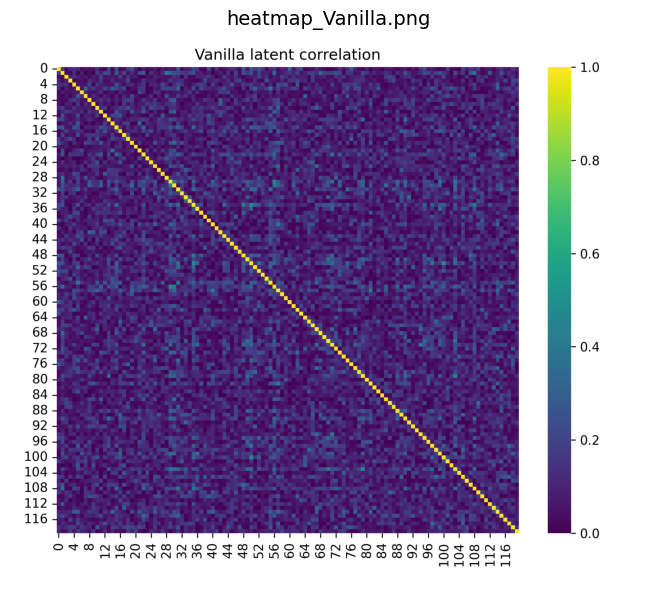

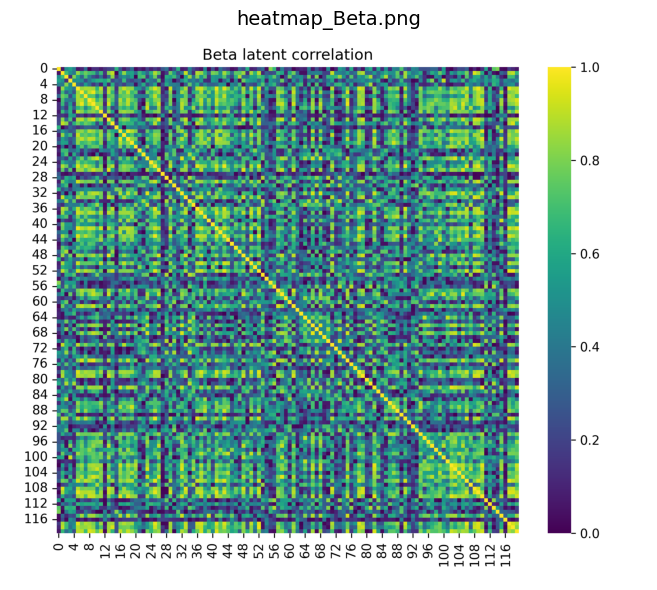

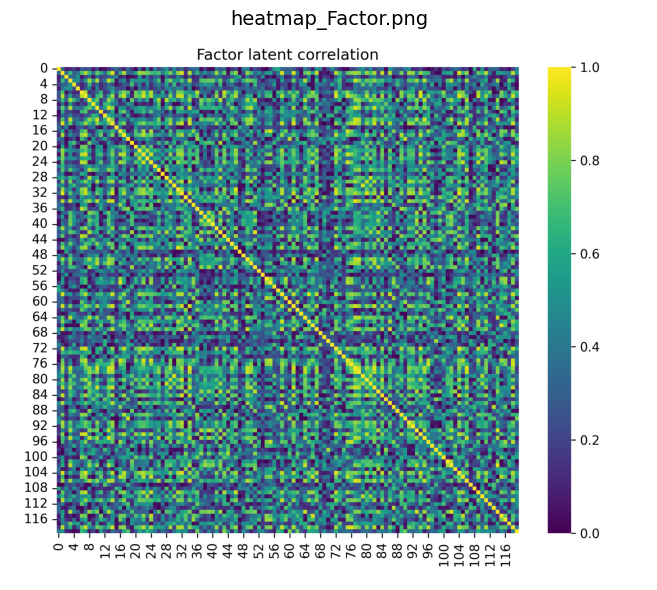

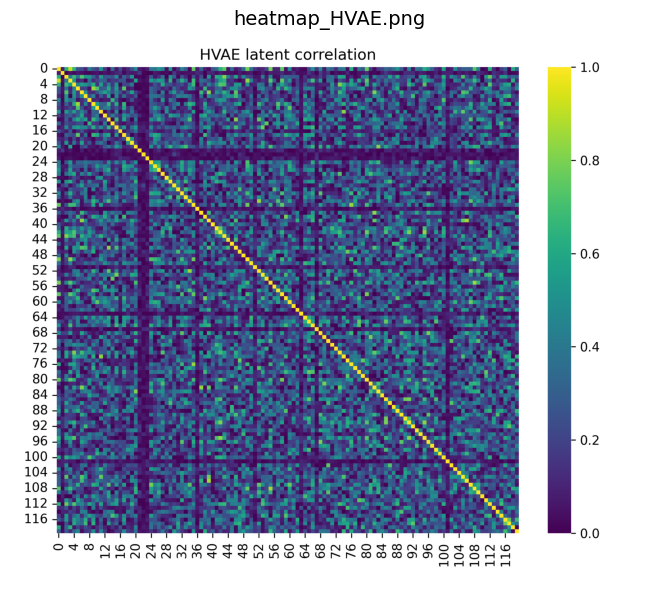

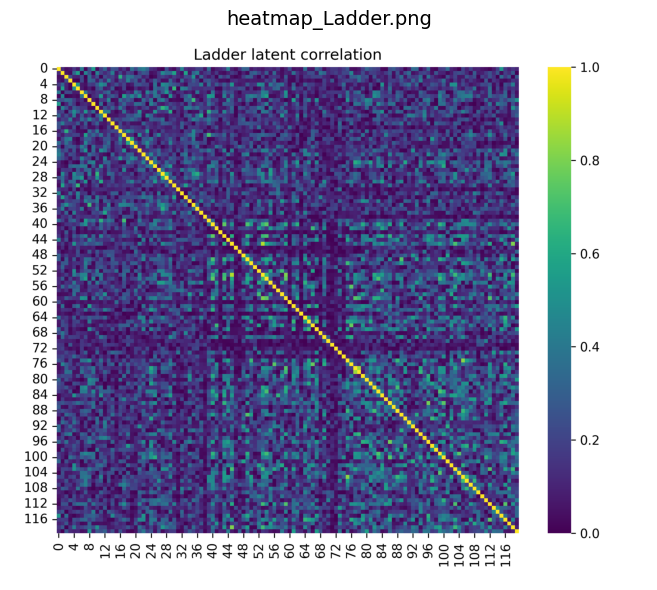

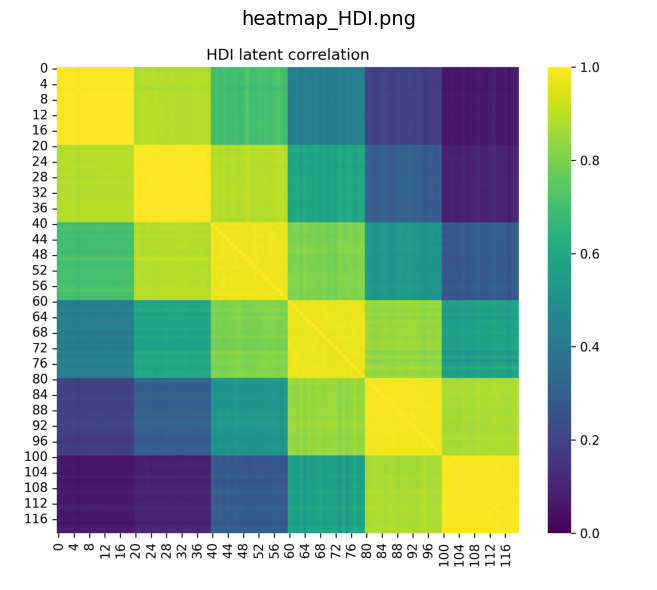

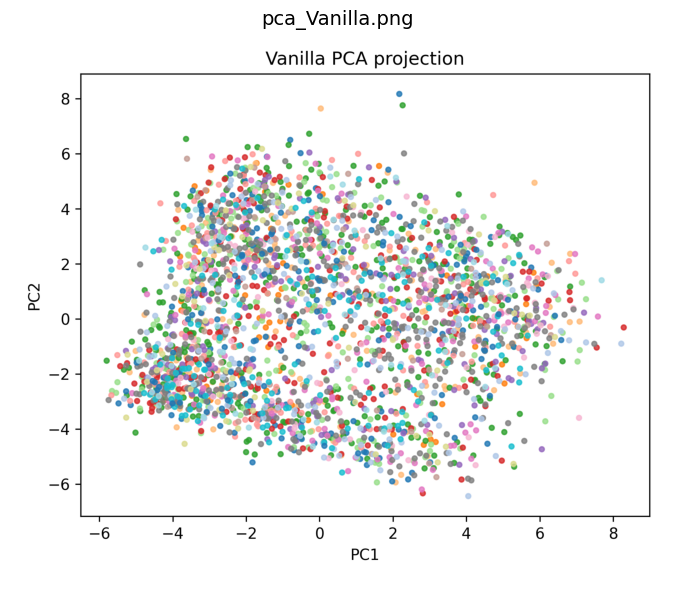

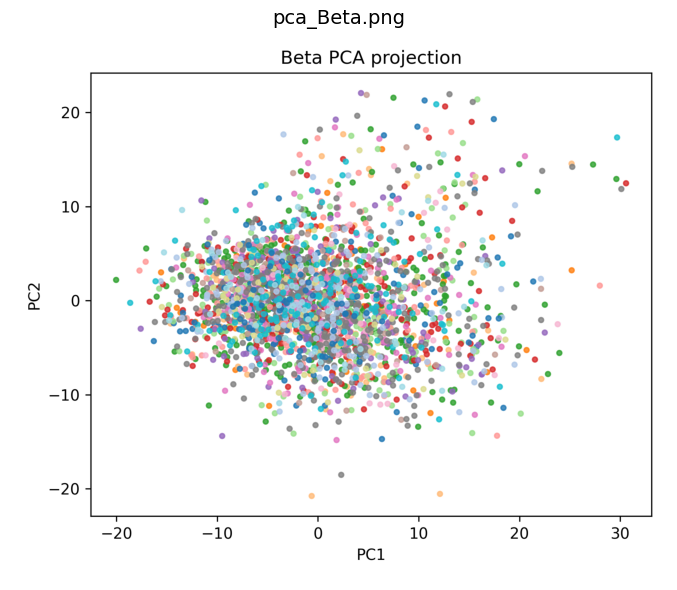

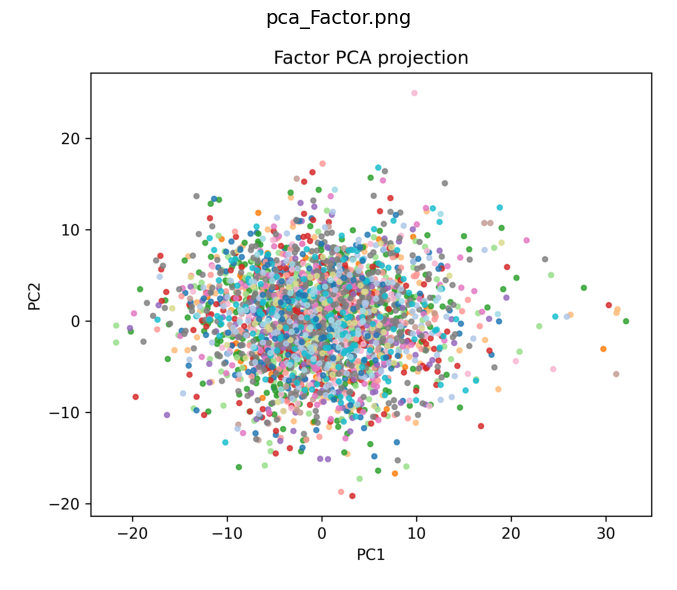

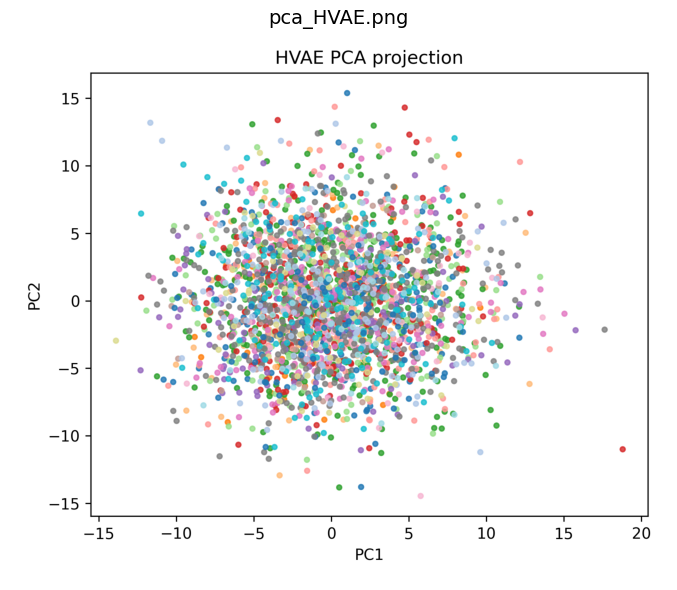

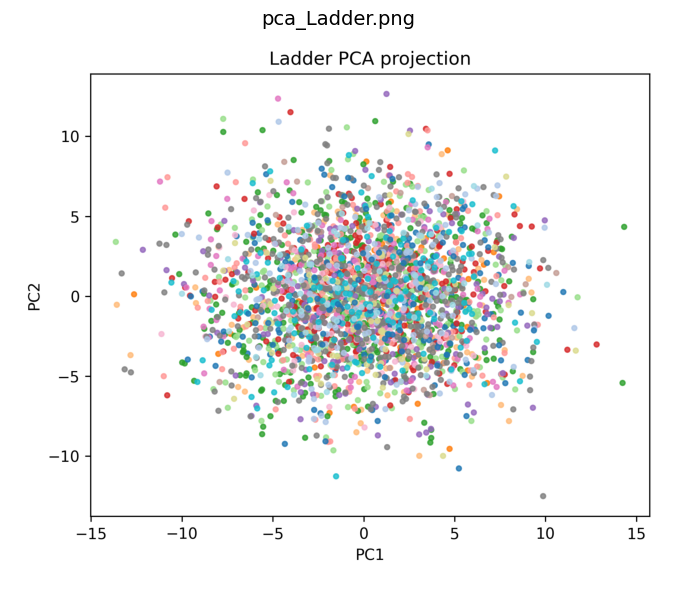

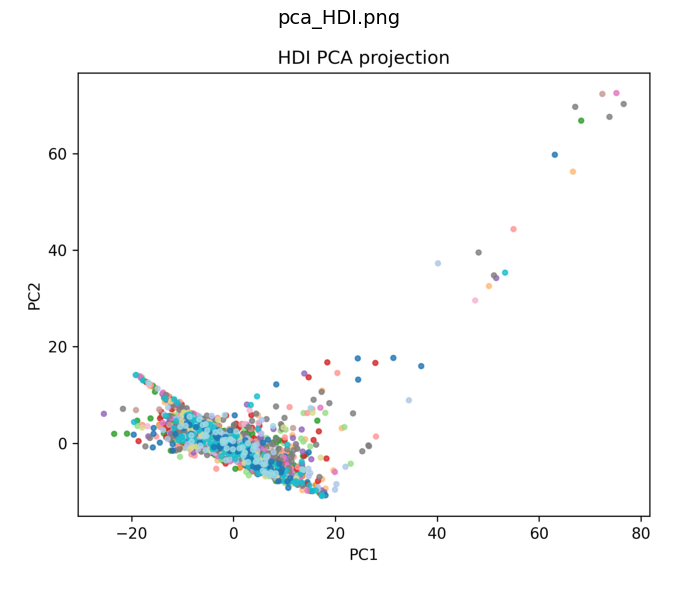

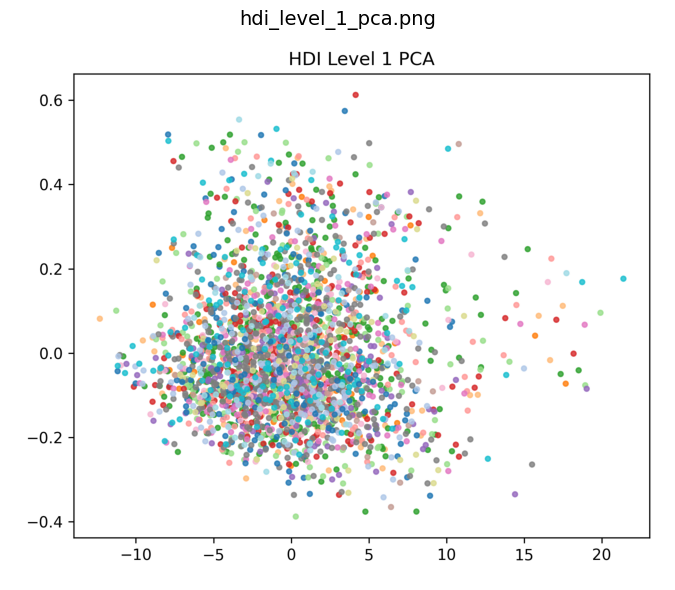

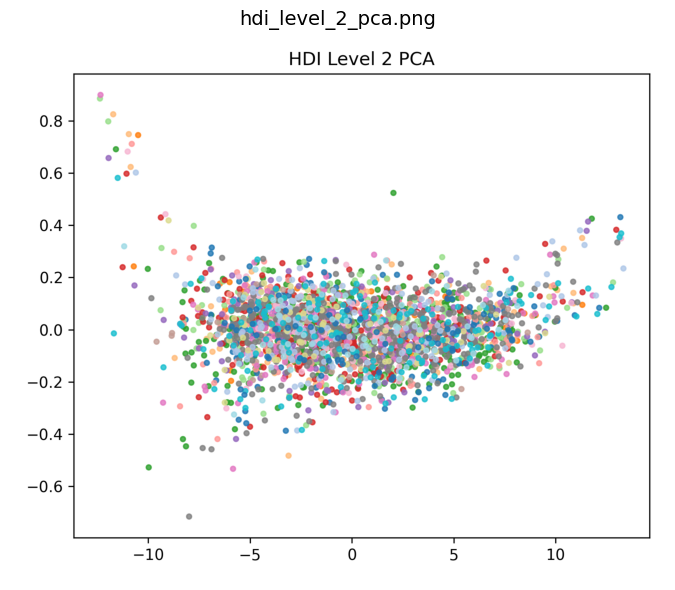

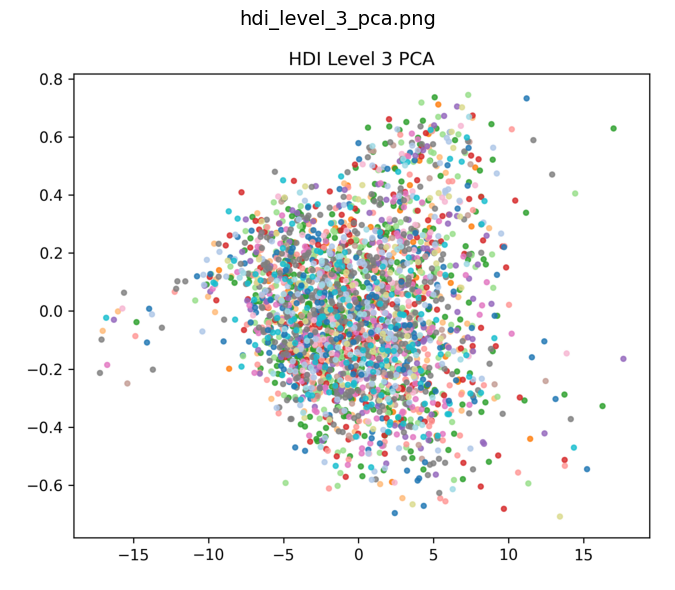

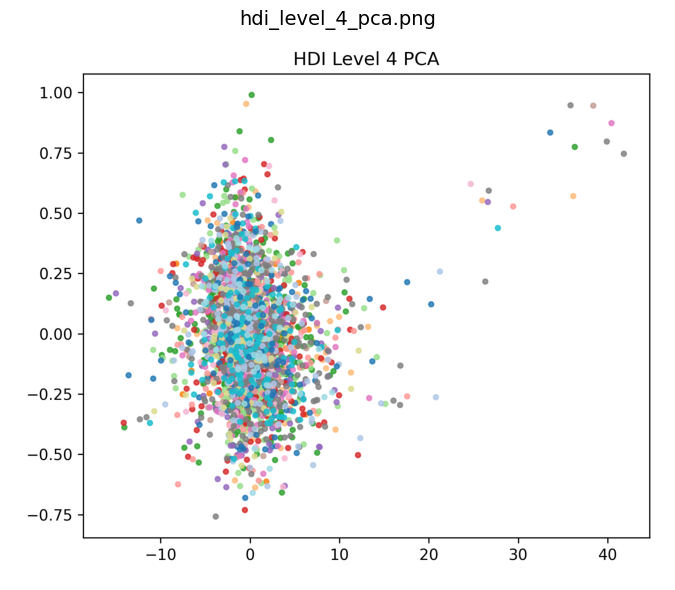

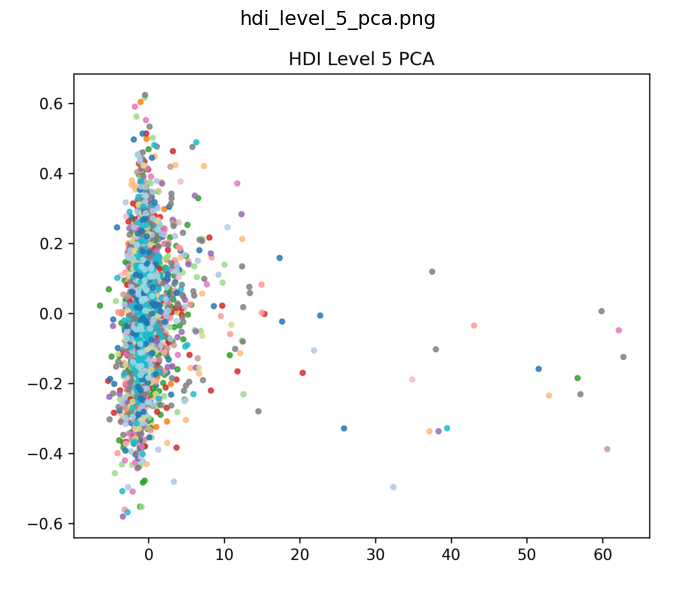

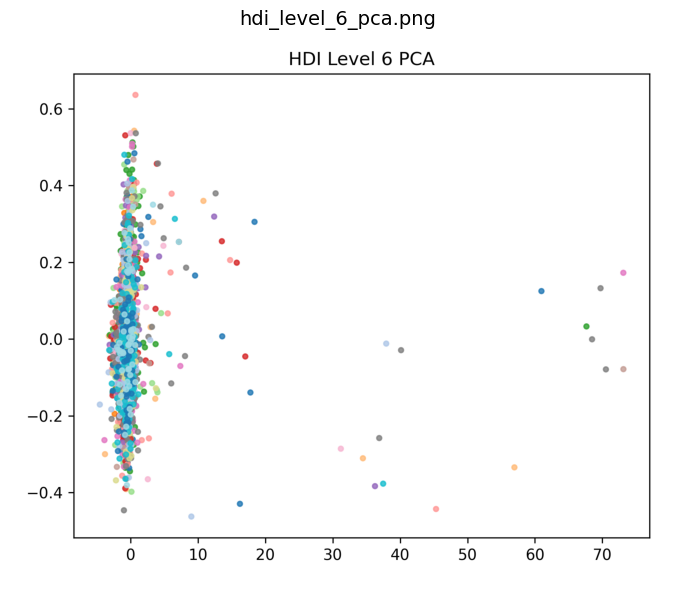

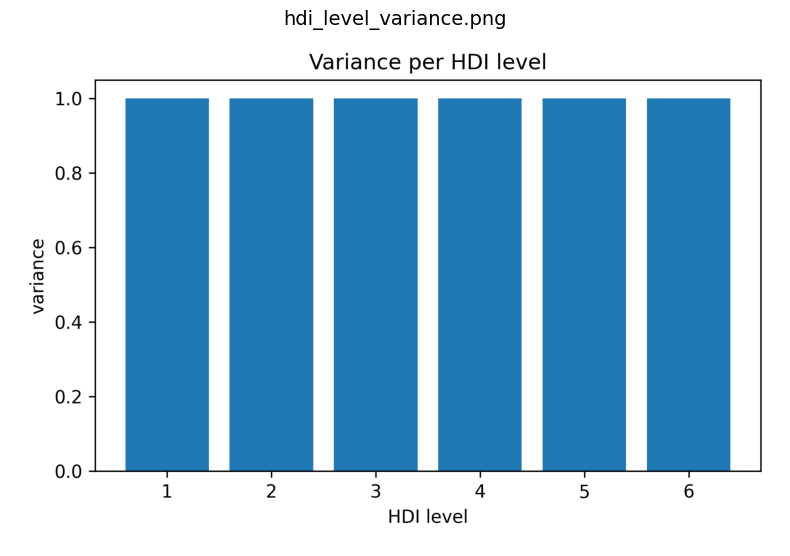

In [34]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ===============================
# Ordered figure list
# ===============================

figure_files = [
    # 1. Correlation heatmaps
    "heatmap_Vanilla.png",
    "heatmap_Beta.png",
    "heatmap_Factor.png",
    "heatmap_HVAE.png",
    "heatmap_Ladder.png",
    "heatmap_HDI.png",

    # 2. PCA projections
    "pca_Vanilla.png",
    "pca_Beta.png",
    "pca_Factor.png",
    "pca_HVAE.png",
    "pca_Ladder.png",
    "pca_HDI.png",

    # 3. HDI level-wise PCA
    "hdi_level_1_pca.png",
    "hdi_level_2_pca.png",
    "hdi_level_3_pca.png",
    "hdi_level_4_pca.png",
    "hdi_level_5_pca.png",
    "hdi_level_6_pca.png",

    # 4. HDI variance
    "hdi_level_variance.png",
]

# ===============================
# Display figures one by one
# ===============================

for file in figure_files:
    if not os.path.exists(file):
        print(f"[Missing] {file}")
        continue

    img = mpimg.imread(file)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(file, fontsize=14)
    plt.tight_layout()
    plt.show()


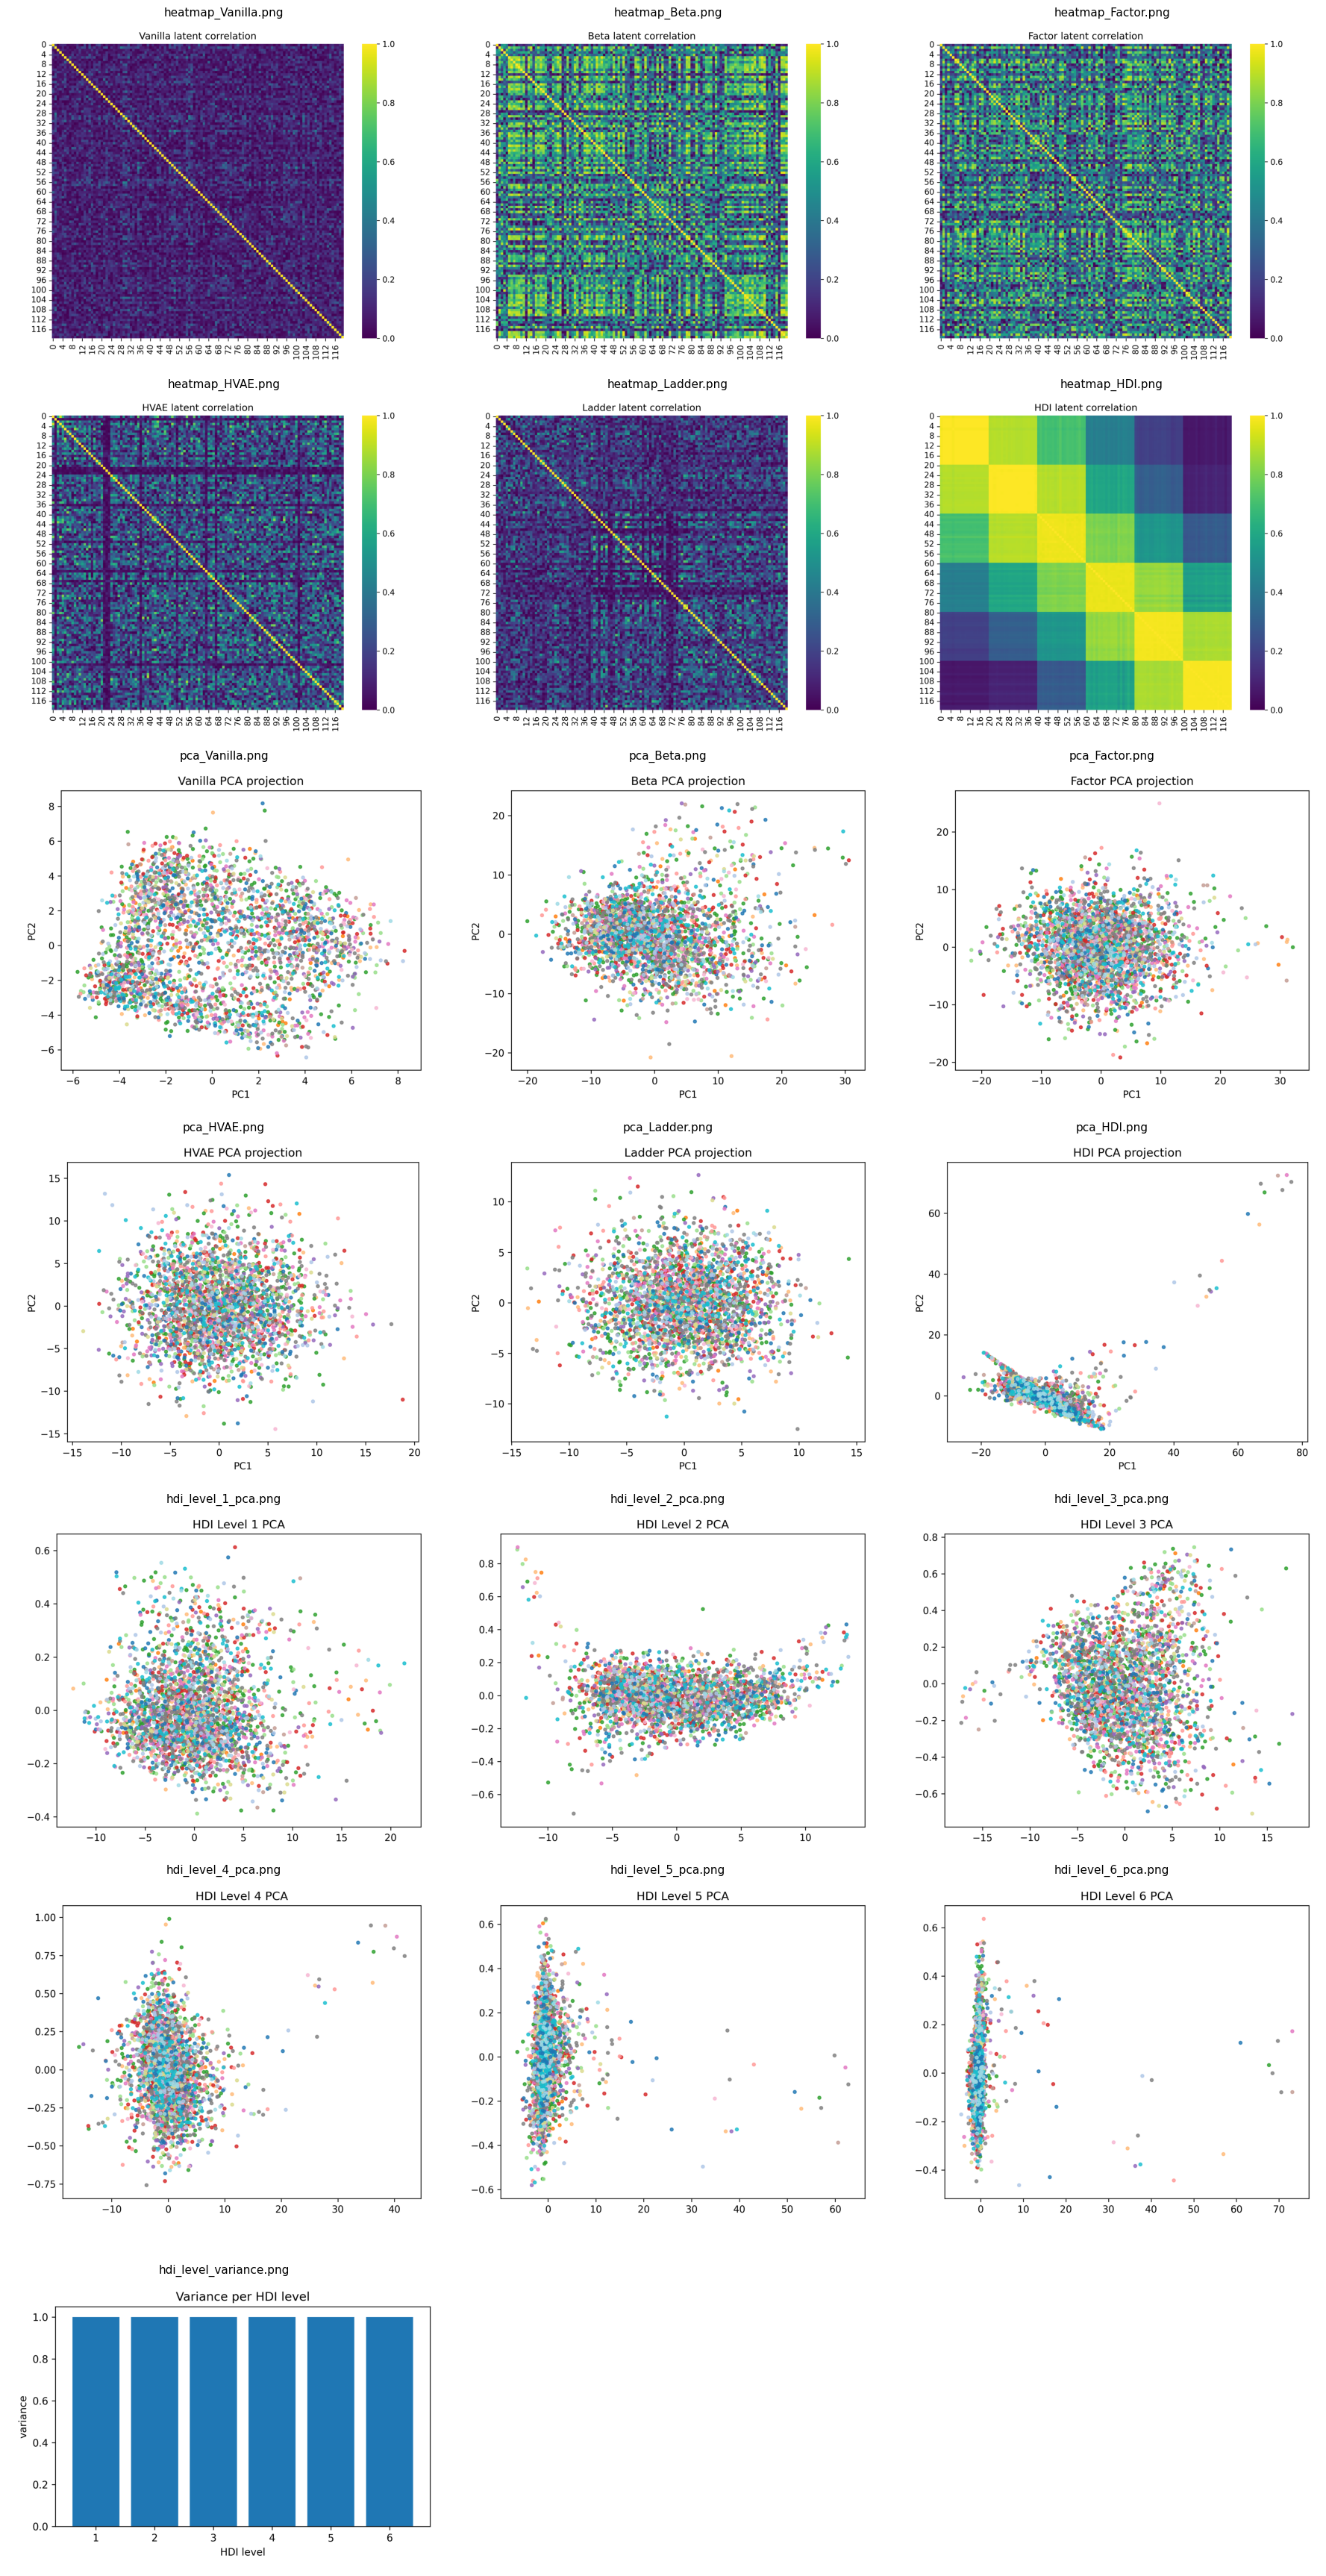

Saved: all_figures_contact_sheet.png


In [35]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

figure_files = [
    "heatmap_Vanilla.png",
    "heatmap_Beta.png",
    "heatmap_Factor.png",
    "heatmap_HVAE.png",
    "heatmap_Ladder.png",
    "heatmap_HDI.png",

    "pca_Vanilla.png",
    "pca_Beta.png",
    "pca_Factor.png",
    "pca_HVAE.png",
    "pca_Ladder.png",
    "pca_HDI.png",

    "hdi_level_1_pca.png",
    "hdi_level_2_pca.png",
    "hdi_level_3_pca.png",
    "hdi_level_4_pca.png",
    "hdi_level_5_pca.png",
    "hdi_level_6_pca.png",

    "hdi_level_variance.png",
]

existing_files = [f for f in figure_files if os.path.exists(f)]

cols = 3
rows = math.ceil(len(existing_files) / cols)

plt.figure(figsize=(cols * 6, rows * 5))

for i, file in enumerate(existing_files):
    img = mpimg.imread(file)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(file, fontsize=11)

plt.tight_layout()
plt.savefig("all_figures_contact_sheet.png", dpi=300)
plt.show()

print("Saved: all_figures_contact_sheet.png")


In [ ]:
# مرحله 1: Level-wise Speaker Analysis

In [36]:
# build_speaker_labels.py

import os
import numpy as np
from pathlib import Path

mel_dir = Path("data/librispeech_mel/dev-clean")
out_path = "speaker_labels.npy"

mel_files = sorted(mel_dir.glob("*.pt"))

speaker_ids = []
file_names = []

for path in mel_files:
    name = path.stem
    speaker_id = name.split("_")[0]
    speaker_ids.append(speaker_id)
    file_names.append(path.name)

unique_speakers = sorted(set(speaker_ids))
speaker_to_idx = {spk: i for i, spk in enumerate(unique_speakers)}

labels = np.array([speaker_to_idx[spk] for spk in speaker_ids], dtype=np.int64)

np.save(out_path, labels)
np.save("speaker_file_names.npy", np.array(file_names))
np.save("speaker_id_strings.npy", np.array(speaker_ids))
np.save("speaker_to_idx.npy", speaker_to_idx, allow_pickle=True)

print("Saved:", out_path)
print("Number of samples:", len(labels))
print("Number of speakers:", len(unique_speakers))
print("First 10 labels:", labels[:10])
print("First 10 files:", file_names[:10])


Saved: speaker_labels.npy
Number of samples: 2703
Number of speakers: 40
First 10 labels: [0 0 0 0 0 0 0 0 0 0]
First 10 files: ['1272_128104_0.pt', '1272_128104_1.pt', '1272_128104_10.pt', '1272_128104_11.pt', '1272_128104_12.pt', '1272_128104_13.pt', '1272_128104_14.pt', '1272_128104_2.pt', '1272_128104_3.pt', '1272_128104_4.pt']


In [38]:
import os
import json
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def load_hdi_levels(latent_dir):
    latent_dir = Path(latent_dir)

    patterns = [
        "latent_hdi_level*.npy",
        "hdi_level_*.npy",
        "hdi_level*.npy",
    ]

    level_files = []

    for pattern in patterns:
        files = list(latent_dir.glob(pattern))
        if len(files) > 0:
            level_files = files
            break

    def extract_level_number(path):
        name = path.stem

        # handles:
        # latent_hdi_level1
        # latent_hdi_level_1
        # hdi_level1
        # hdi_level_1
        import re
        nums = re.findall(r"\d+", name)
        if len(nums) == 0:
            return 999
        return int(nums[-1])

    level_files = sorted(level_files, key=extract_level_number)

    if len(level_files) > 0:
        levels = []
        print("Found HDI level files:")
        for path in level_files:
            z = np.load(path)
            levels.append(z)
            print(f"  {path.name}: {z.shape}")
        return levels

    # fallback 1
    hdi_levels_path = latent_dir / "hdi_levels.npy"
    if hdi_levels_path.exists():
        arr = np.load(hdi_levels_path, allow_pickle=True)
        print("Loaded hdi_levels.npy:", arr.shape)

        if arr.dtype == object:
            return list(arr)

        if arr.ndim == 3:
            return [arr[i] for i in range(arr.shape[0])]

        raise ValueError(f"Unsupported hdi_levels.npy shape: {arr.shape}")

    # fallback 2
    hdi_all_path = latent_dir / "latent_hdi_all.npy"
    if hdi_all_path.exists():
        arr = np.load(hdi_all_path)
        print("Found latent_hdi_all.npy:", arr.shape)
        print(
            "Warning: latent_hdi_all.npy is the concatenated/full HDI latent, "
            "not level-wise. For level-wise analysis, separate level files are preferred."
        )

    raise FileNotFoundError(
        "Could not find latent_hdi_level*.npy, hdi_level_*.npy, or hdi_levels.npy"
    )


def evaluate_linear_probe(z, y, test_size=0.25, seed=42):
    x_train, x_test, y_train, y_test = train_test_split(
        z,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            multi_class="auto",
            class_weight="balanced",
            n_jobs=-1,
        ),
    )

    clf.fit(x_train, y_train)
    pred = clf.predict(x_test)

    return {
        "speaker_acc": float(accuracy_score(y_test, pred)),
        "speaker_balanced_acc": float(balanced_accuracy_score(y_test, pred)),
        "speaker_macro_f1": float(f1_score(y_test, pred, average="macro")),
    }


def evaluate_cv_probe(z, y, seed=42):
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            multi_class="auto",
            class_weight="balanced",
            n_jobs=-1,
        ),
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    acc = cross_val_score(clf, z, y, cv=cv, scoring="accuracy", n_jobs=-1)
    bacc = cross_val_score(clf, z, y, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
    f1 = cross_val_score(clf, z, y, cv=cv, scoring="f1_macro", n_jobs=-1)

    return {
        "speaker_cv_acc_mean": float(acc.mean()),
        "speaker_cv_acc_std": float(acc.std()),
        "speaker_cv_balanced_acc_mean": float(bacc.mean()),
        "speaker_cv_balanced_acc_std": float(bacc.std()),
        "speaker_cv_macro_f1_mean": float(f1.mean()),
        "speaker_cv_macro_f1_std": float(f1.std()),
    }


def evaluate_clustering(z, y, seed=42):
    num_speakers = len(np.unique(y))

    z_scaled = StandardScaler().fit_transform(z)

    kmeans = KMeans(
        n_clusters=num_speakers,
        random_state=seed,
        n_init=20,
    )
    clusters = kmeans.fit_predict(z_scaled)

    out = {
        "speaker_cluster_nmi": float(normalized_mutual_info_score(y, clusters)),
        "speaker_cluster_ari": float(adjusted_rand_score(y, clusters)),
    }

    try:
        out["speaker_cluster_silhouette"] = float(silhouette_score(z_scaled, y))
    except Exception:
        out["speaker_cluster_silhouette"] = None

    return out


def effective_rank(z, eps=1e-12):
    z = z - z.mean(axis=0, keepdims=True)
    cov = np.cov(z, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.maximum(eigvals, 0)
    probs = eigvals / (eigvals.sum() + eps)
    entropy = -np.sum(probs * np.log(probs + eps))
    return float(np.exp(entropy))


def evaluate_level_statistics(z):
    return {
        "num_samples": int(z.shape[0]),
        "dim": int(z.shape[1]),
        "latent_var_mean": float(np.var(z, axis=0).mean()),
        "latent_var_std": float(np.var(z, axis=0).std()),
        "effective_rank": effective_rank(z),
    }


def main():
    latent_dir = "."
    label_path = "speaker_labels.npy"
    out_path = "hdi_levelwise_speaker_results.json"

    y = np.load(label_path)
    levels = load_hdi_levels(latent_dir)

    results = {}

    for i, z in enumerate(levels, start=1):
        print()
        print("=" * 80)
        print(f"Evaluating HDI Level {i}")
        print("=" * 80)

        if len(z) != len(y):
            raise ValueError(
                f"Length mismatch at level {i}: z has {len(z)} samples, labels have {len(y)}"
            )

        level_result = {}
        level_result.update(evaluate_level_statistics(z))
        level_result.update(evaluate_linear_probe(z, y))
        level_result.update(evaluate_cv_probe(z, y))
        level_result.update(evaluate_clustering(z, y))

        results[f"level_{i}"] = level_result

        for k, v in level_result.items():
            print(f"{k}: {v}")

    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)

    print()
    print("Saved results to:", out_path)


if __name__ == "__main__":
    main()


Found HDI level files:
  latent_hdi_level1.npy: (2703, 20)
  latent_hdi_level2.npy: (2703, 20)
  latent_hdi_level3.npy: (2703, 20)
  latent_hdi_level4.npy: (2703, 20)
  latent_hdi_level5.npy: (2703, 20)
  latent_hdi_level6.npy: (2703, 20)

Evaluating HDI Level 1
num_samples: 2703
dim: 20
latent_var_mean: 0.004292914643883705
latent_var_std: 0.0027228083927184343
effective_rank: 1.0362157268095804
speaker_acc: 0.023668639053254437
speaker_balanced_acc: 0.026238201110483715
speaker_macro_f1: 0.014628188086456124
speaker_cv_acc_mean: 0.019982200314917504
speaker_cv_acc_std: 0.008149847744988368
speaker_cv_balanced_acc_mean: 0.023602089796168742
speaker_cv_balanced_acc_std: 0.009836942272067559
speaker_cv_macro_f1_mean: 0.010409820996127838
speaker_cv_macro_f1_std: 0.006289037338359361
speaker_cluster_nmi: 0.08176269795453403
speaker_cluster_ari: -0.00037451978421436074
speaker_cluster_silhouette: -0.18092206120491028

Evaluating HDI Level 2
num_samples: 2703
dim: 20
latent_var_mean: 0.013

In [ ]:
# Stage 2: Content probing

In [45]:
import numpy as np
from pathlib import Path
import re
import json

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score


# -----------------------------
# Load HDI levels
# -----------------------------

def load_hdi_levels():

    files = sorted(Path(".").glob("latent_hdi_level*.npy"))

    levels = []
    for f in files:
        z = np.load(f)
        levels.append(z)
        print(f"{f.name}: {z.shape}")

    return levels


# -----------------------------
# Build char vocabulary
# -----------------------------

def build_char_vocab():

    chars = list("abcdefghijklmnopqrstuvwxyz ")

    char_to_idx = {c: i for i, c in enumerate(chars)}

    return char_to_idx


# -----------------------------
# Text → histogram
# -----------------------------

def text_to_histogram(text, vocab):

    vec = np.zeros(len(vocab))

    text = text.lower()

    for c in text:
        if c in vocab:
            vec[vocab[c]] += 1

    if vec.sum() > 0:
        vec = vec / vec.sum()

    return vec


# -----------------------------
# Load transcripts
# -----------------------------

def load_transcripts(librispeech_root):

    transcripts = {}

    trans_files = list(Path(librispeech_root).rglob("*.trans.txt"))

    for tf in trans_files:

        with open(tf) as f:

            for line in f:

                parts = line.strip().split(" ", 1)

                if len(parts) != 2:
                    continue

                utt_id, text = parts

                transcripts[utt_id] = text

    print("Loaded transcripts:", len(transcripts))

    return transcripts


# -----------------------------
# Build content matrix
# -----------------------------

def build_content_matrix(utt_ids, transcripts, vocab):

    feats = []

    for uid in utt_ids:

        text = transcripts.get(uid, "")

        vec = text_to_histogram(text, vocab)

        feats.append(vec)

    return np.array(feats)


# -----------------------------
# Content probe
# -----------------------------

def evaluate_probe(z, y):

    x_train, x_test, y_train, y_test = train_test_split(
        z,
        y,
        test_size=0.25,
        random_state=0,
    )

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    )

    model.fit(x_train, y_train)

    pred = model.predict(x_test)

    r2 = r2_score(y_test, pred)

    return float(r2)


# -----------------------------
# Main
# -----------------------------

def main():

    librispeech_root = "data/LibriSpeech/dev-clean"
    mel_dir = "data/librispeech_mel/dev-clean"

    levels = load_hdi_levels()

    transcripts = load_transcripts(librispeech_root)

    vocab = build_char_vocab()

    mel_files = sorted(Path(mel_dir).glob("*.pt"))


    def mel_to_librispeech_id(name):

        parts = name.split("_")
    
        speaker = parts[0]
        chapter = parts[1]
        utt = int(parts[2])
        return f"{speaker}-{chapter}-{utt:04d}"
    utt_ids = [mel_to_librispeech_id(f.stem) for f in mel_files]


    print("Utterances:", len(utt_ids))

    content = build_content_matrix(utt_ids, transcripts, vocab)

    print("Example IDs:")
    print(utt_ids[:5])
    print("Content matrix:", content.shape)
    print("Content variance:", content.var())


    results = {}

    for i, z in enumerate(levels, start=1):

        print()
        print("Evaluating level", i)

        r2 = evaluate_probe(z, content)

        print("Content R2:", r2)

        results[f"level_{i}"] = {
            "content_r2": r2
        }

    with open("hdi_content_probe_results.json", "w") as f:
        json.dump(results, f, indent=2)

    print()
    print("Saved to hdi_content_probe_results.json")


if __name__ == "__main__":
    main()


latent_hdi_level1.npy: (2703, 20)
latent_hdi_level2.npy: (2703, 20)
latent_hdi_level3.npy: (2703, 20)
latent_hdi_level4.npy: (2703, 20)
latent_hdi_level5.npy: (2703, 20)
latent_hdi_level6.npy: (2703, 20)
Loaded transcripts: 2703
Utterances: 2703
Example IDs:
['1272-128104-0000', '1272-128104-0001', '1272-128104-0010', '1272-128104-0011', '1272-128104-0012']
Content matrix: (2703, 27)
Content variance: 0.0018633867049715324

Evaluating level 1
Content R2: -0.005445040951062792

Evaluating level 2
Content R2: -0.007904800464304538

Evaluating level 3
Content R2: -0.010421041569639045

Evaluating level 4
Content R2: -0.009577778109885696

Evaluating level 5
Content R2: -0.012068490138158031

Evaluating level 6
Content R2: -0.010593752361704982

Saved to hdi_content_probe_results.json


In [ ]:
# آزمایش اول: HuBERT Content Probing

In [46]:
pip install transformers torchaudio

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 7.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 KB 5.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 KB 7.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 KB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 8.5 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 KB 2.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.1/794.1 KB 5.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 KB 1.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 6.7 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 KB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
pip install -U transformers huggingface_hub


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip uninstall transformers -y
!pip uninstall transformers -y


Found existing installation: transformers 5.12.1
Uninstalling transformers-5.12.1:
  Successfully uninstalled transformers-5.12.1


In [5]:
pip install transformers==4.41.2

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 5.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 KB 10.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packag

In [6]:
pip install accelerate sentencepiece

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 KB 1.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.6 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [1]:
from transformers import HubertModel

print("HubertModel loaded")


/home/jupyter/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HubertModel loaded


In [4]:
import torch
import torchaudio
import numpy as np
from pathlib import Path
from transformers import HubertModel, Wav2Vec2FeatureExtractor
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"

wav_root = Path("data/LibriSpeech/dev-clean")
mel_dir = Path("data/librispeech_mel/dev-clean")


feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/hubert-base-ls960"
)

model = HubertModel.from_pretrained(
    "facebook/hubert-base-ls960"
).to(device)

model.eval()


def mel_to_wav_path(mel_name):
    """
    convert:
    84_121123_0  ->  data/LibriSpeech/dev-clean/84/121123/84-121123-0000.flac
    """

    parts = mel_name.split("_")

    speaker = parts[0]
    chapter = parts[1]
    utt = int(parts[2])

    wav_name = f"{speaker}-{chapter}-{utt:04d}.flac"

    wav_path = wav_root / speaker / chapter / wav_name

    return wav_path


mel_files = sorted(mel_dir.glob("*.pt"))

print("Mel files:", len(mel_files))

embeddings = []

for m in tqdm(mel_files):
    # print('m= ',m)

    wav_path = mel_to_wav_path(m.stem)

    if not wav_path.exists():
        raise ValueError(f"WAV not found: {wav_path}")

    wav, sr = torchaudio.load(wav_path)

    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)

    inputs = feature_extractor(
        wav.squeeze().numpy(),
        sampling_rate=16000,
        return_tensors="pt"
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        out = model(input_values)

    hidden = out.last_hidden_state

    emb = hidden.mean(dim=1).cpu().numpy()

    embeddings.append(emb.squeeze())


embeddings = np.array(embeddings)

print("HuBERT embeddings:", embeddings.shape)

np.save("hubert_content_embeddings.npy", embeddings)


Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for pre

Mel files: 2703


100%|██████████| 2703/2703 [10:40<00:00,  4.22it/s]

HuBERT embeddings: (2703, 768)


In [5]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score


levels = [
    np.load("latent_hdi_level1.npy"),
    np.load("latent_hdi_level2.npy"),
    np.load("latent_hdi_level3.npy"),
    np.load("latent_hdi_level4.npy"),
    np.load("latent_hdi_level5.npy"),
    np.load("latent_hdi_level6.npy"),
]

content = np.load("hubert_content_embeddings.npy")

print("Content shape:", content.shape)


def probe(z, y):

    x_train, x_test, y_train, y_test = train_test_split(
        z, y, test_size=0.25, random_state=0
    )

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    )

    model.fit(x_train, y_train)

    pred = model.predict(x_test)

    return r2_score(y_test, pred)


for i, z in enumerate(levels, 1):

    r2 = probe(z, content)

    print(f"Level {i}  R2: {r2:.4f}")


Content shape: (2703, 768)
Level 1  R2: -0.0055
Level 2  R2: -0.0077
Level 3  R2: -0.0126
Level 4  R2: -0.0129
Level 5  R2: -0.0140
Level 6  R2: -0.0104


In [6]:
import numpy as np


def analyze(name, z):

    var = np.var(z, axis=0)

    print()
    print(name)
    print("mean var:", var.mean())
    print("std var:", var.std())
    print("max/min:", var.max() / (var.min() + 1e-8))


hdi = np.load("latent_hdi_all.npy")
vae = np.load("latent_vanilla.npy")
beta = np.load("latent_beta.npy")

analyze("HDI", hdi)
analyze("VAE", vae)
analyze("BetaVAE", beta)



HDI
mean var: 0.044194404
std var: 0.03225166
max/min: 39.89719705952815

VAE
mean var: 99.177216
std var: 18.401146
max/min: 2.253469691220464

BetaVAE
mean var: 0.0045363153
std var: 0.03790581
max/min: 4186.515137294538


In [8]:
# MRH: Saving Hubert Model
from transformers import HubertModel, Wav2Vec2FeatureExtractor

model_name = "facebook/hubert-base-ls960"

model = HubertModel.from_pretrained(model_name)
extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
 
model.save_pretrained("hubert_local")
extractor.save_pretrained("hubert_local")

print("model saved to hubert_local/")


Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for pre

model saved to hubert_local/


In [ ]:
# Latent Ablation Hierarchy Test
# Reconstruction Sensitivity Curve
# Level Traversal Visualization

In [11]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class HierarchicalEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1,32,3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128,128,3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.projections = nn.ModuleList([
            nn.Linear(32,20),
            nn.Linear(64,20),
            nn.Linear(128,20),
            nn.Linear(128,20),
            nn.Linear(128,20),
            nn.Linear(128,20)
        ])

    def forward(self,x):

        f1 = self.conv1(x)
        f2 = self.conv2(f1)
        f3 = self.conv3(f2)
        f4 = self.conv4(f3)

        pooled = [
            self.pool(f1).view(x.size(0),-1),
            self.pool(f2).view(x.size(0),-1),
            self.pool(f3).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
            self.pool(f4).view(x.size(0),-1),
        ]

        z_levels = [
            self.projections[i](pooled[i])
            for i in range(6)
        ]

        z = torch.cat(z_levels, dim=1)

        return z, z_levels


########################################
# Decoder
########################################

class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(120,128*5*5)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128,128,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,4,stride=2,padding=1)
        )

    def forward(self,z):

        x = self.fc(z)
        x = x.view(-1,128,5,5)
        x = self.deconv(x)

        return x


########################################
# Model
########################################

class HDIModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = HierarchicalEncoder()
        self.decoder = Decoder()

    def forward(self,x):

        z, levels = self.encoder(x)
        recon = self.decoder(z)

        return recon, levels


/tmp/ipykernel_5018/960754369.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("hdi_model_best.pt", map_location=device)


Model loaded


100%|██████████| 85/85 [00:05<00:00, 14.90it/s]


Ablation sensitivity per level:
Level 1: 0.036595
Level 2: 0.046264
Level 3: 0.068597
Level 4: 0.099116
Level 5: 0.117786
Level 6: 0.123112
Saved: hdi_ablation_curve.png
Traversal images saved
Saved: hdi_level_contribution.png


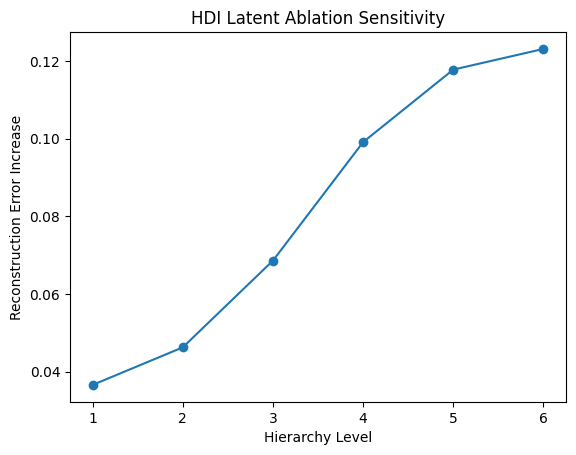

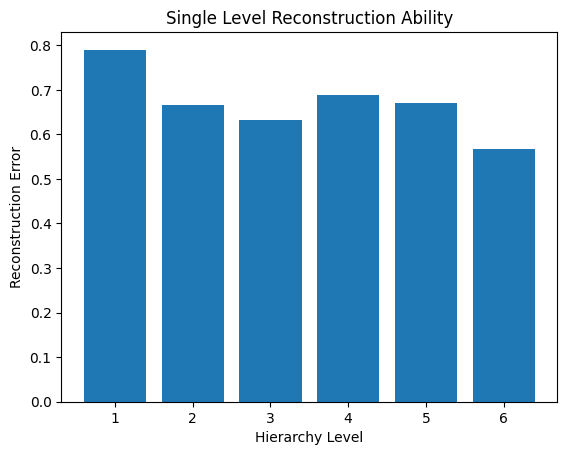

In [16]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


########################################
# Dataset
########################################

class MelDataset(Dataset):

    def __init__(self, root):
        self.files = [
            os.path.join(root, f)
            for f in os.listdir(root)
            if f.endswith(".pt")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        x = torch.load(self.files[idx], weights_only=True)

        # force fixed size 80x80
        if x.shape[2] > 80:
            x = x[:, :, :80]
        else:
            pad = 80 - x.shape[2]
            x = F.pad(x, (0, pad))

        return x

#from model import HDIModel   # همان فایل مدل

device = torch.device("cpu")

############################################
# Load model
############################################

model = HDIModel().to(device)

ckpt = torch.load("hdi_model_best.pt", map_location=device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Model loaded")

############################################
# Load dataset
############################################


dataset = MelDataset("data/librispeech_mel/dev-clean")

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=False
)

############################################
# 1) Latent Ablation Test
############################################

level_errors = np.zeros(6)

with torch.no_grad():

    for batch in tqdm(loader):

        batch = batch.to(device)

        recon, levels = model(batch)

        base_error = F.mse_loss(recon, batch, reduction="none")
        base_error = base_error.mean([1,2,3])

        for i in range(6):

            modified_levels = []

            for j,l in enumerate(levels):

                if j == i:
                    modified_levels.append(torch.zeros_like(l))
                else:
                    modified_levels.append(l)

            z = torch.cat(modified_levels, dim=1)

            recon_mod = model.decoder(z)

            error = F.mse_loss(recon_mod, batch, reduction="none")
            error = error.mean([1,2,3])

            diff = (error - base_error).mean().item()

            level_errors[i] += diff


level_errors /= len(loader)

print("Ablation sensitivity per level:")
for i,e in enumerate(level_errors):
    print(f"Level {i+1}: {e:.6f}")

############################################
# Plot sensitivity curve
############################################

plt.figure()

plt.plot(
    np.arange(1,7),
    level_errors,
    marker="o"
)

plt.xlabel("Hierarchy Level")
plt.ylabel("Reconstruction Error Increase")
plt.title("HDI Latent Ablation Sensitivity")

plt.savefig("hdi_ablation_curve.png", dpi=300)

print("Saved: hdi_ablation_curve.png")

############################################
# 2) Level Traversal Visualization
############################################

sample = dataset[0].unsqueeze(0).to(device)

with torch.no_grad():

    _, levels = model(sample)

levels = [l.clone() for l in levels]

steps = np.linspace(-3,3,7)

for level in range(6):

    imgs = []

    for s in steps:

        mod_levels = [l.clone() for l in levels]

        mod_levels[level][:,0] += s

        z = torch.cat(mod_levels, dim=1)

        recon = model.decoder(z)

        # imgs.append(recon.squeeze().cpu().numpy())
        imgs.append(recon.squeeze().detach().numpy())

    fig,axs = plt.subplots(1,len(imgs),figsize=(14,2))

    for i,img in enumerate(imgs):

        axs[i].imshow(img,aspect="auto",origin="lower")
        axs[i].axis("off")

    plt.savefig(f"traversal_level_{level+1}.png",dpi=300)
    plt.close()

print("Traversal images saved")

############################################
# 3) Reconstruction contribution per level
############################################

contributions = []

with torch.no_grad():

    for i in range(6):

        total = 0

        for batch in loader:

            batch = batch.to(device)

            _, levels = model(batch)

            z = torch.zeros(batch.size(0),120).to(device)

            start = i*20
            end = (i+1)*20

            z[:,start:end] = levels[i]

            recon = model.decoder(z)

            loss = F.mse_loss(recon,batch)

            total += loss.item()

        contributions.append(total/len(loader))


plt.figure()

plt.bar(np.arange(1,7), contributions)

plt.xlabel("Hierarchy Level")
plt.ylabel("Reconstruction Error")
plt.title("Single Level Reconstruction Ability")

plt.savefig("hdi_level_contribution.png", dpi=300)

print("Saved: hdi_level_contribution.png")


In [ ]:
# آزمایش “Latent Swapping”

# اگر دو تا فایل صوتی مختلف داشته باشیم (
# 𝐴
#  و 
# 𝐵
# سطح ۶ِ فایل 
# 𝐴
#  را با سطح ۶ِ فایل 
# B
#  عوض کن.
# ببین بازسازی خروجی چه شکلی می‌شود.
# اگر سطح ۶ مسئول Speaker است، باید timbre (رنگ صدا) عوض شود ولی متن ثابت بماند.
# اگر مسئول Content است، باید متن عوض شود ولی timbre ثابت بماند.
# اگر موافقی، بگو تا اسکریپت latent_swapping.py را بنویسم. این کار می‌تواند تیر خلاص برای اثبات Disentanglement در مقاله باشد.



/tmp/ipykernel_5018/3751347499.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("hdi_model_best.pt", map_location=device)


Saved: latent_swapping_results.png


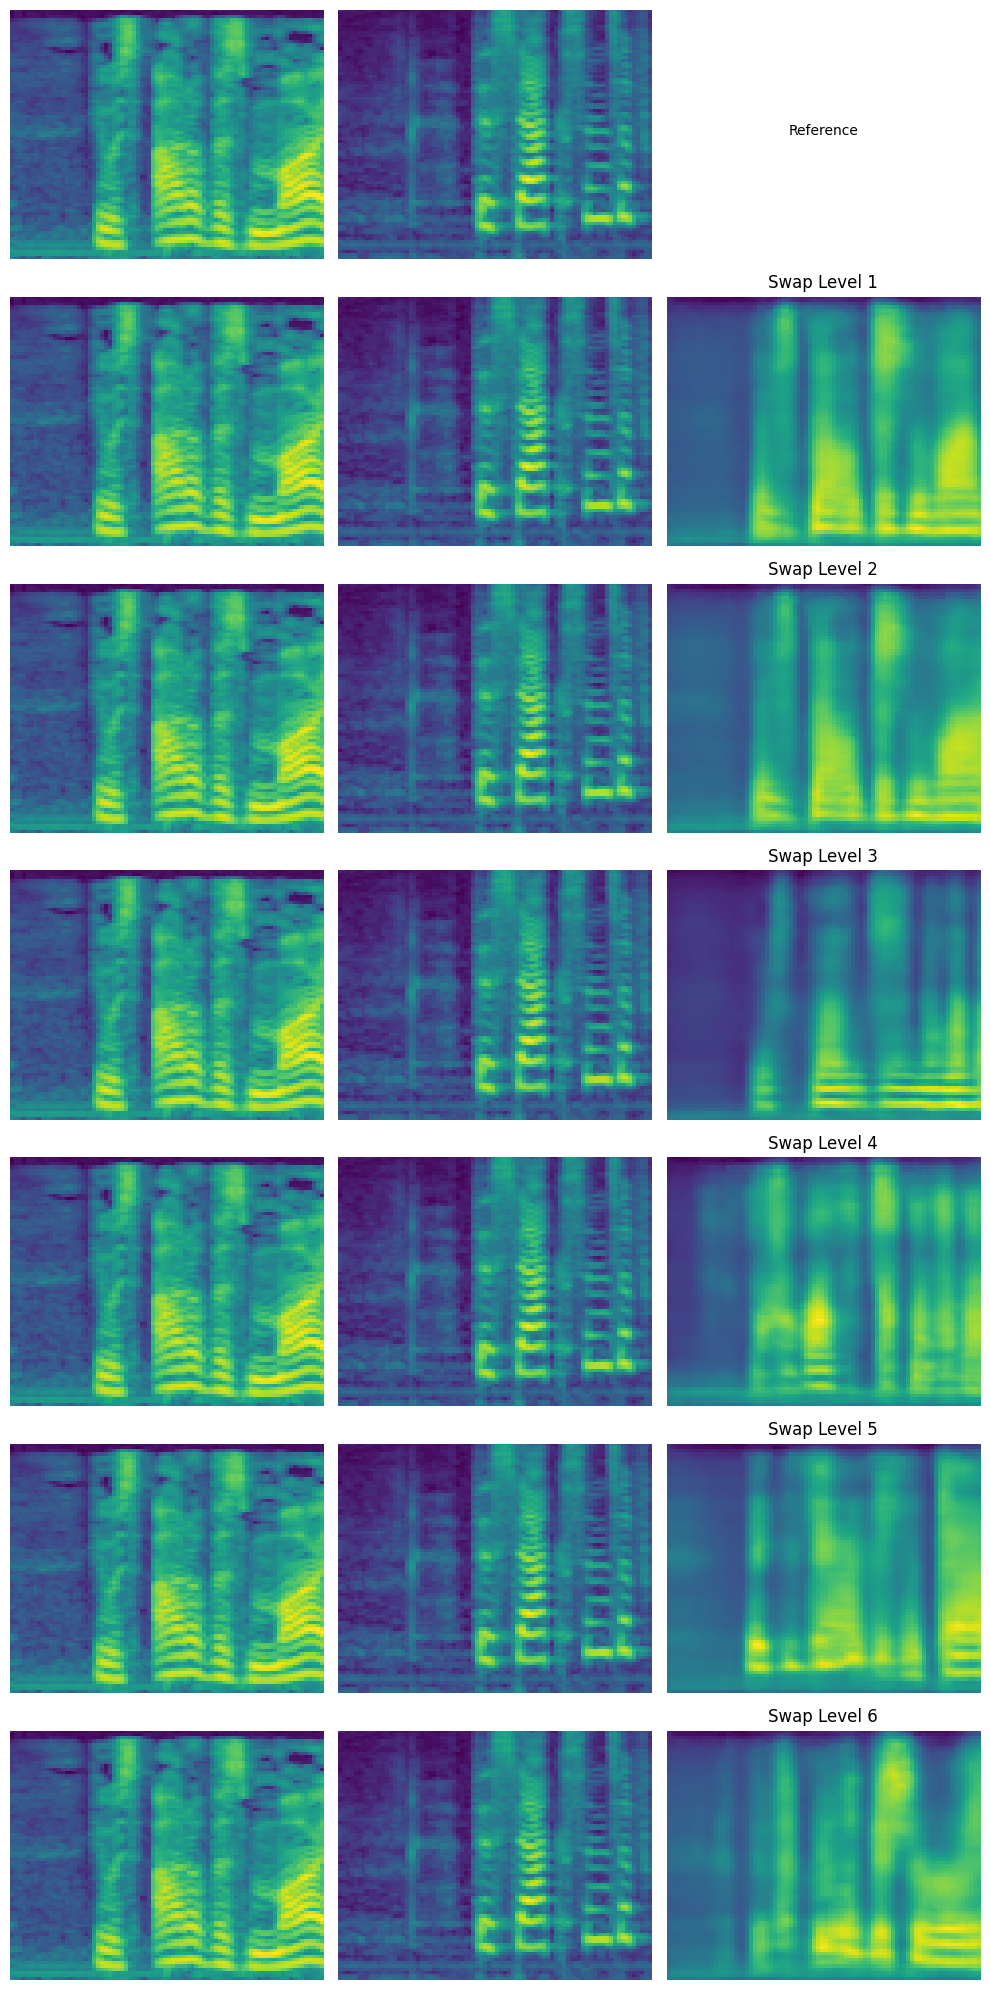

In [19]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# from model import HDIModel
# from dataset import MelDataset

device = torch.device("cpu")
model = HDIModel().to(device)
ckpt = torch.load("hdi_model_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

dataset = MelDataset("data/librispeech_mel/dev-clean")
# انتخاب دو نمونه متفاوت
sample_a = dataset[0].unsqueeze(0).to(device)
sample_b = dataset[10].unsqueeze(0).to(device) # نمونه دهم برای تفاوت بیشتر

with torch.no_grad():
    _, levels_a = model(sample_a)
    _, levels_b = model(sample_b)

# رسم نتایج
fig, axes = plt.subplots(7, 3, figsize=(10, 20))
titles = ["Original A", "Original B", "Swapped Result"]

# ستون اول: Original A (ثابت)
# ستون دوم: Original B (ثابت)
# ستون سوم: نتیجه جایگزینی سطح i
for i in range(7):
    # تنظیمات نمایش
    if i == 0:
        axes[i, 0].imshow(sample_a.squeeze().cpu().numpy(), aspect="auto", origin="lower")
        axes[i, 1].imshow(sample_b.squeeze().cpu().numpy(), aspect="auto", origin="lower")
        axes[i, 2].text(0.5, 0.5, "Reference", ha='center')
        axes[i, 2].axis('off')
    else:
        level_idx = i - 1
        # ساخت ترکیب جدید
        mixed_levels = [l.clone() for l in levels_a]
        mixed_levels[level_idx] = levels_b[level_idx].clone()
        
        # بازسازی
        z = torch.cat(mixed_levels, dim=1)
        recon = model.decoder(z)
        
        # نمایش
        axes[i, 0].imshow(sample_a.squeeze().detach().numpy(), aspect="auto", origin="lower")
        axes[i, 1].imshow(sample_b.squeeze().detach().numpy(), aspect="auto", origin="lower")
        axes[i, 2].imshow(recon.squeeze().detach().numpy(), aspect="auto", origin="lower")
        axes[i, 2].set_title(f"Swap Level {level_idx+1}")

    for j in range(3):
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig("latent_swapping_results.png", dpi=300)
print("Saved: latent_swapping_results.png")
